# HT-CapsNet Output Analysis

This notebook analyzes seeded HT-CapsNet training and selected-checkpoint test artifacts in `/scratch/g.saggini1/outputs/`. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across available seeds.

Selected run families:

- native HT-CapsNet baselines with next-batch dynamic level weights,
- explicit gradient-space lexicographic runs with unit level weights,
- the exploratory HT-CapsNet + HCC hard-projection ablation.

Protocol scope:

- CIFAR-100 uses the local paper/source-aligned preset and the repository's 8/20/100 hierarchy.
- The incompatible historical CIFAR-100 `seed_42` artifact is explicitly excluded: it used a different image size, split, attention implementation, optimizer settings, and schedule.
- CUB uses the repository's 13/38/200 taxonomy rather than the paper's 39/123/200 taxonomy.
- Aircraft is a local 64 px extrapolation; HT-CapsNet was not evaluated on Aircraft in the source study.
- Top-down and independent results remain separate. Each test metric family is read from the checkpoint selected for that same decoding mode.

The per-seed margin-collapse screen below must be read before aggregate curves or tables. A completed `test_metrics.yaml` does not by itself establish that a capsule run learned a discriminative solution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HTCapsNetAnalysis,
    HCastAnalysisConfig as HTCapsNetAnalysisConfig,
    _normalize_dataset_key,
    _parse_single_run,
    resolve_project_root,
    show_markdown,
)
from multiseed_utils import (
    aggregate_parsed_seed_runs,
    discover_seed_dirs,
    metric_series_with_std,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')

Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = True
BASELINE_COLOR = '#243ab4'

DATASET_SLUGS = {
    'cifar-100': 'cifar100',
    'cub-200-2011': 'cub200',
    'fgvc-aircraft': 'aircraft',
}
HT_CAPSNET_DATASETS = tuple(DATASET_SLUGS.values())

BASELINE_BY_DATASET = {
    dataset_key: {
        'run_dir': f'capsnet_{dataset}',
        'label': 'HT-CapsNet baseline (dynamic weights)',
    }
    for dataset_key, dataset in DATASET_SLUGS.items()
}

MANUAL_RUNS = [
    *[
        {
            'run_dir': f'ht_capsnet_{dataset}_lex_orthogonalize_all_coarse_first',
            'label': 'HT-CapsNet lex coarse-first (unit weights)',
        }
        for dataset in HT_CAPSNET_DATASETS
    ],
    *[
        {
            'run_dir': f'capsnet_hcc_{dataset}_step_0epoch',
            'label': 'HT-CapsNet + HCC (exploratory)',
        }
        for dataset in HT_CAPSNET_DATASETS
    ],
]

RUN_COLOR_PALETTE = [
    '#d62728', '#2ca02c', '#ff7f0e', '#9467bd',
    '#8c564b', '#17becf', '#e377c2', '#bcbd22',
]

# Historical seed_42 predates the corrected attention projections, uses a
# different image size/split/schedule, and is not comparable with the current
# seeded CIFAR-100 run. Keep exclusions explicit instead of silently pooling it.
EXCLUDED_SEEDS_BY_RUN = {
    'capsnet_cifar100': {42},
}

In [3]:
config = HTCapsNetAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=RUN_COLOR_PALETTE,
)


def build_protocol_homogeneous_analysis(config, excluded_seeds_by_run):
    run_specs = HTCapsNetAnalysis._build_runs_from_manual(config)
    if config.include_baselines:
        HTCapsNetAnalysis._append_dataset_baselines(config, run_specs)
    if not run_specs:
        print('No runs found. Check MANUAL_RUNS/BASELINE_BY_DATASET and output paths.')
        return HTCapsNetAnalysis(config=config, run_data_list=[])

    parsed_runs = []
    for run_spec in run_specs:
        run_dir = Path(run_spec['run_dir'])
        excluded = {int(seed) for seed in excluded_seeds_by_run.get(run_dir.name, set())}
        selected_seed_dirs = []
        for seed_dir in discover_seed_dirs(run_dir):
            seed = int(seed_dir.name.replace('seed_', ''))
            if seed in excluded:
                print(f'Excluding incompatible historical seed: {seed_dir}')
                continue
            selected_seed_dirs.append(seed_dir)
        if not selected_seed_dirs:
            print(f'Skipping run with no selected seeds: {run_dir}')
            continue

        parsed_seed_runs = [_parse_single_run(seed_dir) for seed_dir in selected_seed_dirs]
        parsed = aggregate_parsed_seed_runs(run_dir, parsed_seed_runs)
        parsed.update(run_spec)
        dataset_name = parsed.get('dataset_name')
        if not dataset_name:
            dataset_name = parsed.get('config', {}).get('dataset', {}).get('name')
        parsed['dataset_name'] = str(dataset_name)
        parsed['dataset_key'] = _normalize_dataset_key(parsed['dataset_name'])
        parsed['_run_order'] = len(parsed_runs)
        parsed_runs.append(parsed)

    return HTCapsNetAnalysis(config=config, run_data_list=parsed_runs)


analysis = build_protocol_homogeneous_analysis(config, EXCLUDED_SEEDS_BY_RUN)
analysis.print_run_summary()

Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/ht_capsnet_cifar100_lex_orthogonalize_all_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/ht_capsnet_cub200_lex_orthogonalize_all_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/ht_capsnet_aircraft_lex_orthogonalize_all_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_hcc_cifar100_step_0epoch
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_hcc_cub200_step_0epoch
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_hcc_aircraft_step_0epoch
No manual runs found; attempting baseline-only analysis for cifar-100, cub-200-2011, fgvc-aircraft
[cifar-100] HT-CapsNet baseline (dynamic weights): epochs=32, best_td_epoch=7.0, best_ind_epoch=7.0, baseline, seeds=[0]
[cub-200-2011] HT-CapsNet baseline (dynamic weights): epochs=200, best_td_epoch=106.0, best_ind_epoch=85.66666666666667, baseline,

## Per-Seed Margin-Collapse Screen

HT-CapsNet can approach a constant capsule-length solution while still producing a complete run. For a balanced `C`-class level with constant length `c`, the margin-loss reference is

`c* = (m+ + lambda (C - 1) m-) / (1 + lambda (C - 1))`.

The table compares the last ten epochs of every seed with that balanced-class reference. It also reports per-level train/validation accuracy and shared-parameter movement. This is a screening aid, not an automatic exclusion rule: class imbalance, MixUp, HCC-corrected scores, and transient dynamics can shift the empirical loss away from the reference.

In [4]:
CLASS_COUNTS_BY_DATASET = {
    'cifar-100': (8, 20, 100),
    'cub-200-2011': (13, 38, 200),
    'fgvc-aircraft': (30, 70, 100),
}


def balanced_constant_margin_minimum(num_classes, m_pos, m_neg, lambda_down):
    absent_weight = lambda_down * (num_classes - 1)
    constant_length = (m_pos + absent_weight * m_neg) / (1.0 + absent_weight)
    loss = (m_pos - constant_length) ** 2
    loss += absent_weight * (constant_length - m_neg) ** 2
    return float(constant_length), float(loss)


def tail_mean(seed_run, mapping_key, metric_key, tail_epochs=10):
    values = []
    for event in seed_run.get('epoch_events', [])[-tail_epochs:]:
        mapping = event.get(mapping_key, {})
        try:
            value = float(mapping.get(metric_key, np.nan))
        except (TypeError, ValueError):
            value = np.nan
        if np.isfinite(value):
            values.append(value)
    return float(np.mean(values)) if values else float('nan')


def format_profile(values, *, percent=False, digits=3):
    formatted = []
    for value in values:
        if not np.isfinite(value):
            formatted.append('n/a')
        elif percent:
            formatted.append(f'{100.0 * value:.1f}')
        else:
            formatted.append(f'{value:.{digits}f}')
    return '/'.join(formatted)


def show_margin_collapse_screen(analysis, tail_epochs=10):
    rows = []
    for dataset_key in analysis.dataset_keys:
        class_counts = CLASS_COUNTS_BY_DATASET[dataset_key]
        for run_data in analysis.run_data_by_dataset.get(dataset_key, []):
            for seed_run in run_data.get('seed_runs', []):
                loss_cfg = seed_run.get('config', {}).get('model', {}).get('loss', {})
                m_pos = float(loss_cfg.get('margin_m_pos', 0.9))
                m_neg = float(loss_cfg.get('margin_m_neg', 0.1))
                lambda_down = float(loss_cfg.get('lambda_downweight', 0.5))
                reference_losses = [
                    balanced_constant_margin_minimum(c, m_pos, m_neg, lambda_down)[1]
                    for c in class_counts
                ]
                train_losses = [
                    tail_mean(seed_run, 'train_losses', f'loss_level_{level}', tail_epochs)
                    for level in range(3)
                ]
                gaps = [abs(value - ref) for value, ref in zip(train_losses, reference_losses)]
                train_acc = [
                    tail_mean(seed_run, 'train_metrics_norm', f'acc_level_independent_{level}', tail_epochs)
                    for level in range(3)
                ]
                val_acc = [
                    tail_mean(seed_run, 'val_metrics_norm', f'acc_level_independent_{level}', tail_epochs)
                    for level in range(3)
                ]
                movement = tail_mean(
                    seed_run, 'train_metrics_norm', 'delta_param_norm_t1', tail_epochs
                )
                epochs = seed_run.get('epoch_events', [])
                last_epoch = int(epochs[-1]['epoch']) if epochs else -1
                seed_name = Path(seed_run['run_dir']).name.replace('seed_', '')
                label = str(run_data['label']).replace('|', '/')
                rows.append(
                    f'| {dataset_key} | {label} | {seed_name} | {last_epoch} | '
                    f'{format_profile(train_losses)} | {format_profile(reference_losses)} | '
                    f'{format_profile(gaps)} | {format_profile(train_acc, percent=True)} | '
                    f'{format_profile(val_acc, percent=True)} | {movement:.4g} |'
                )

    if not rows:
        print('No seed runs available for the collapse screen.')
        return

    header = [
        '| Dataset | Run | Seed | Last epoch | Tail train margin L0/L1/L2 | '
        'Balanced constant ref. | Absolute gap | Tail train acc. L0/L1/L2 (%) | '
        'Tail val acc. L0/L1/L2 (%) | Tail delta-param T1 |',
        '|---|---|---:|---:|---|---|---|---|---|---:|',
    ]
    show_markdown('\n'.join([*header, *rows]))


show_margin_collapse_screen(analysis)

| Dataset | Run | Seed | Last epoch | Tail train margin L0/L1/L2 | Balanced constant ref. | Absolute gap | Tail train acc. L0/L1/L2 (%) | Tail val acc. L0/L1/L2 (%) | Tail delta-param T1 |
|---|---|---:|---:|---|---|---|---|---|---:|
| cifar-100 | HT-CapsNet baseline (dynamic weights) | 0 | 32 | 0.473/0.577/0.627 | 0.498/0.579/0.627 | 0.024/0.002/0.001 | 25.2/5.7/1.1 | 25.5/6.7/1.5 | 43.1 |
| cub-200-2011 | HT-CapsNet baseline (dynamic weights) | 0 | 200 | 0.047/0.088/0.106 | 0.549/0.607/0.634 | 0.501/0.519/0.527 | 73.6/53.6/49.8 | 83.3/58.7/26.5 | 0.006679 |
| cub-200-2011 | HT-CapsNet baseline (dynamic weights) | 1 | 200 | 0.047/0.089/0.106 | 0.549/0.607/0.634 | 0.501/0.518/0.527 | 73.6/53.9/50.1 | 83.9/58.0/30.8 | 0.006825 |
| cub-200-2011 | HT-CapsNet baseline (dynamic weights) | 2 | 200 | 0.047/0.089/0.107 | 0.549/0.607/0.634 | 0.501/0.518/0.527 | 73.7/53.8/50.0 | 84.4/58.8/29.9 | 0.006732 |
| fgvc-aircraft | HT-CapsNet baseline (dynamic weights) | 0 | 71 | 0.537/0.610/0.627 | 0.599/0.622/0.627 | 0.062/0.012/0.001 | 22.0/7.9/1.3 | 22.1/7.9/1.6 | 0.4075 |

Interpretation note:

- Read loss, accuracy, and parameter movement jointly. A small loss-reference gap together with accuracy pinned near a class-prior baseline and very small parameter movement is consistent with collapse; the loss gap alone is not sufficient.
- Inspect every seed before reporting a mean. A collapsed seed can depress the mean and inflate the sample standard deviation while leaving all expected artifact files present.
- Do not remove a seed post hoc from the main comparison. If a health criterion is introduced, define it independently of the result being compared and report both the full-seed and sensitivity analyses.

## Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the same axes: solid lines are top-down, dashed lines are independent, and color identifies the run. FPA and weighted AP are higher-is-better; TICE and AHD are lower-is-better. Shaded bands are one sample standard deviation when multiple seeds contribute at an epoch.

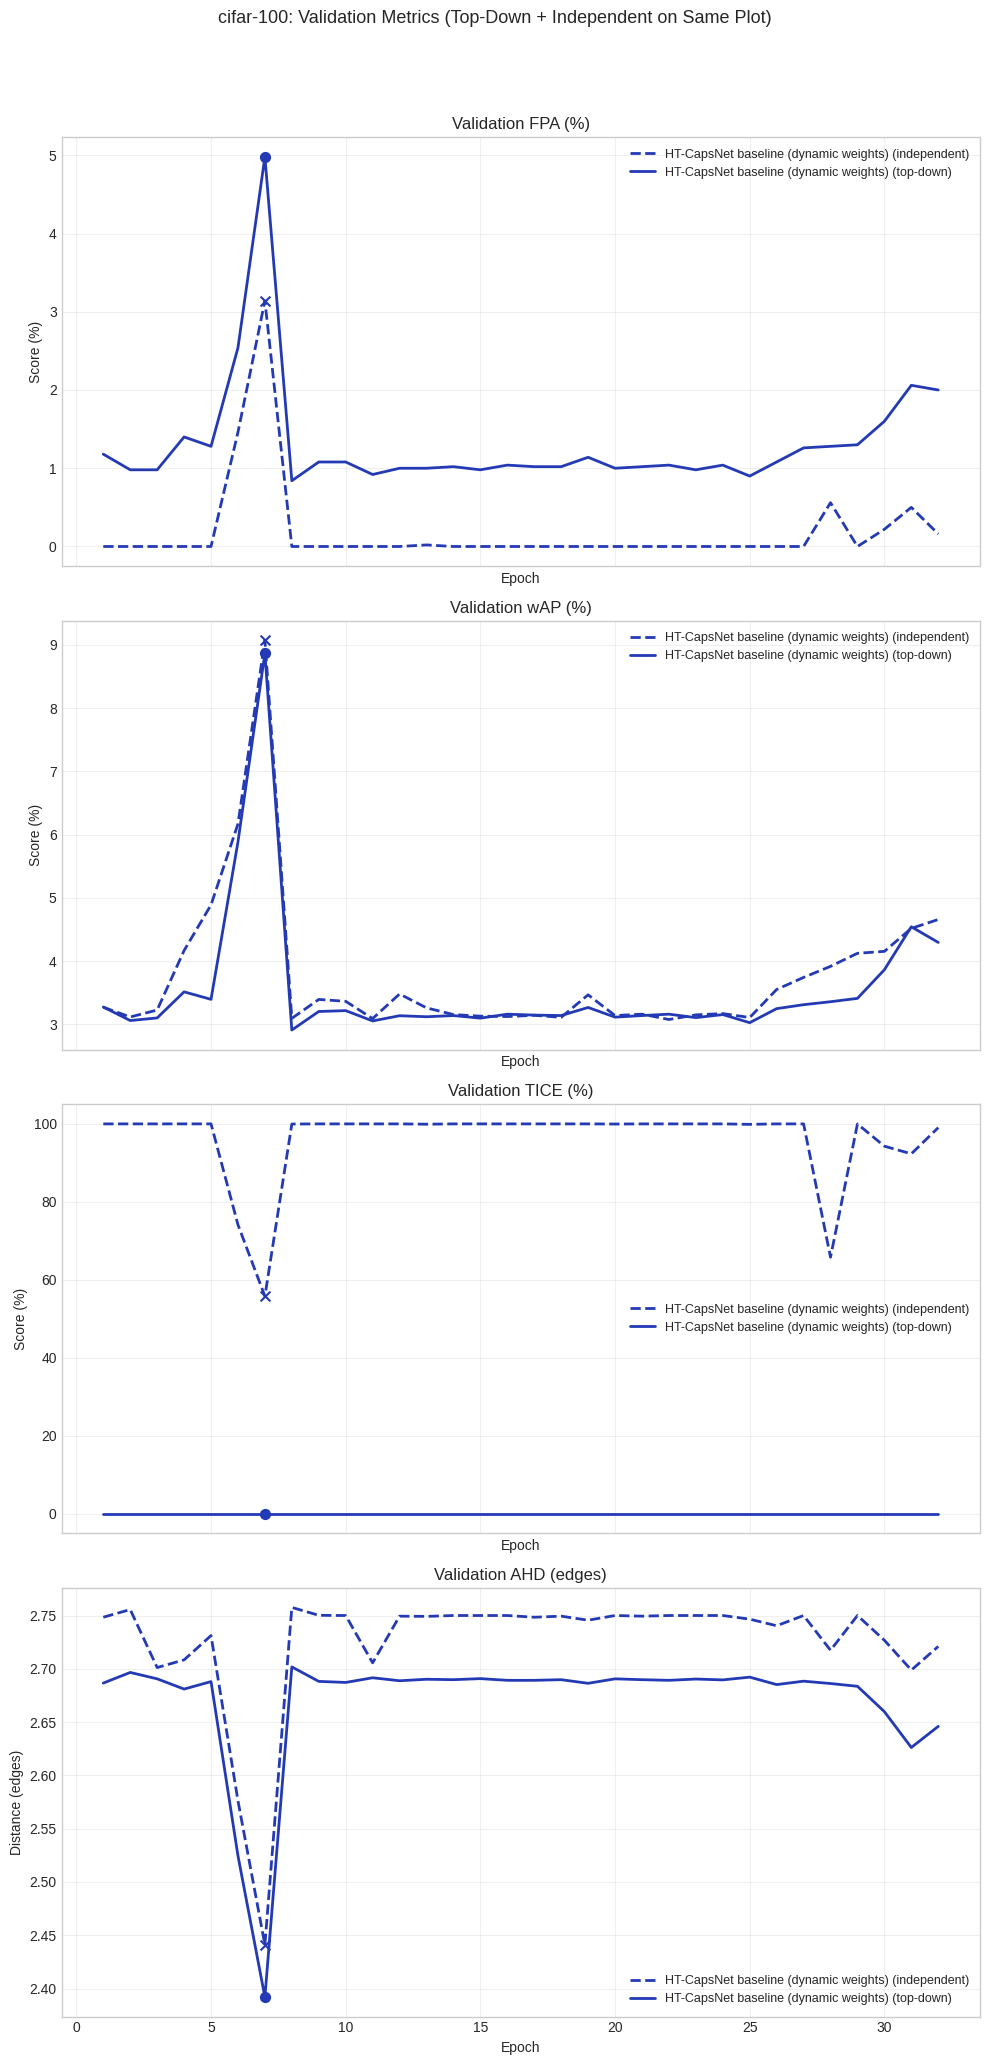

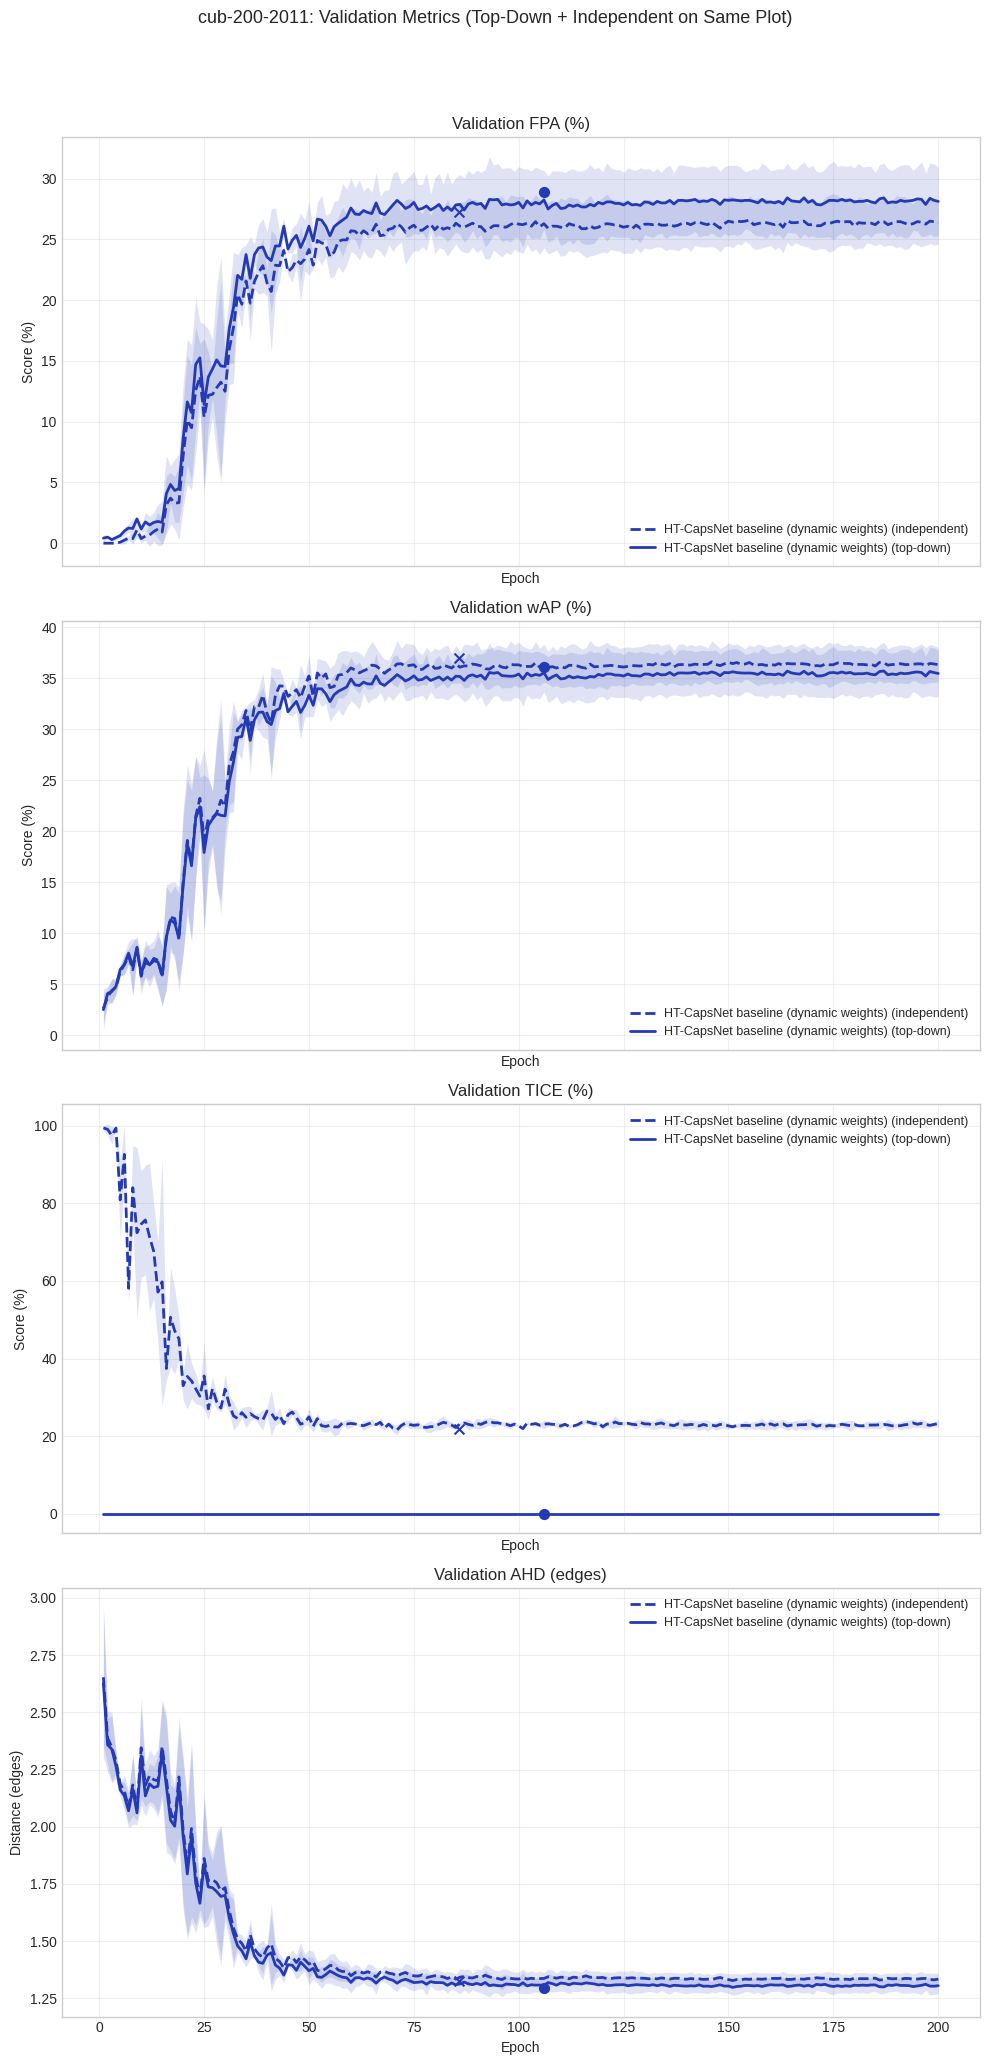

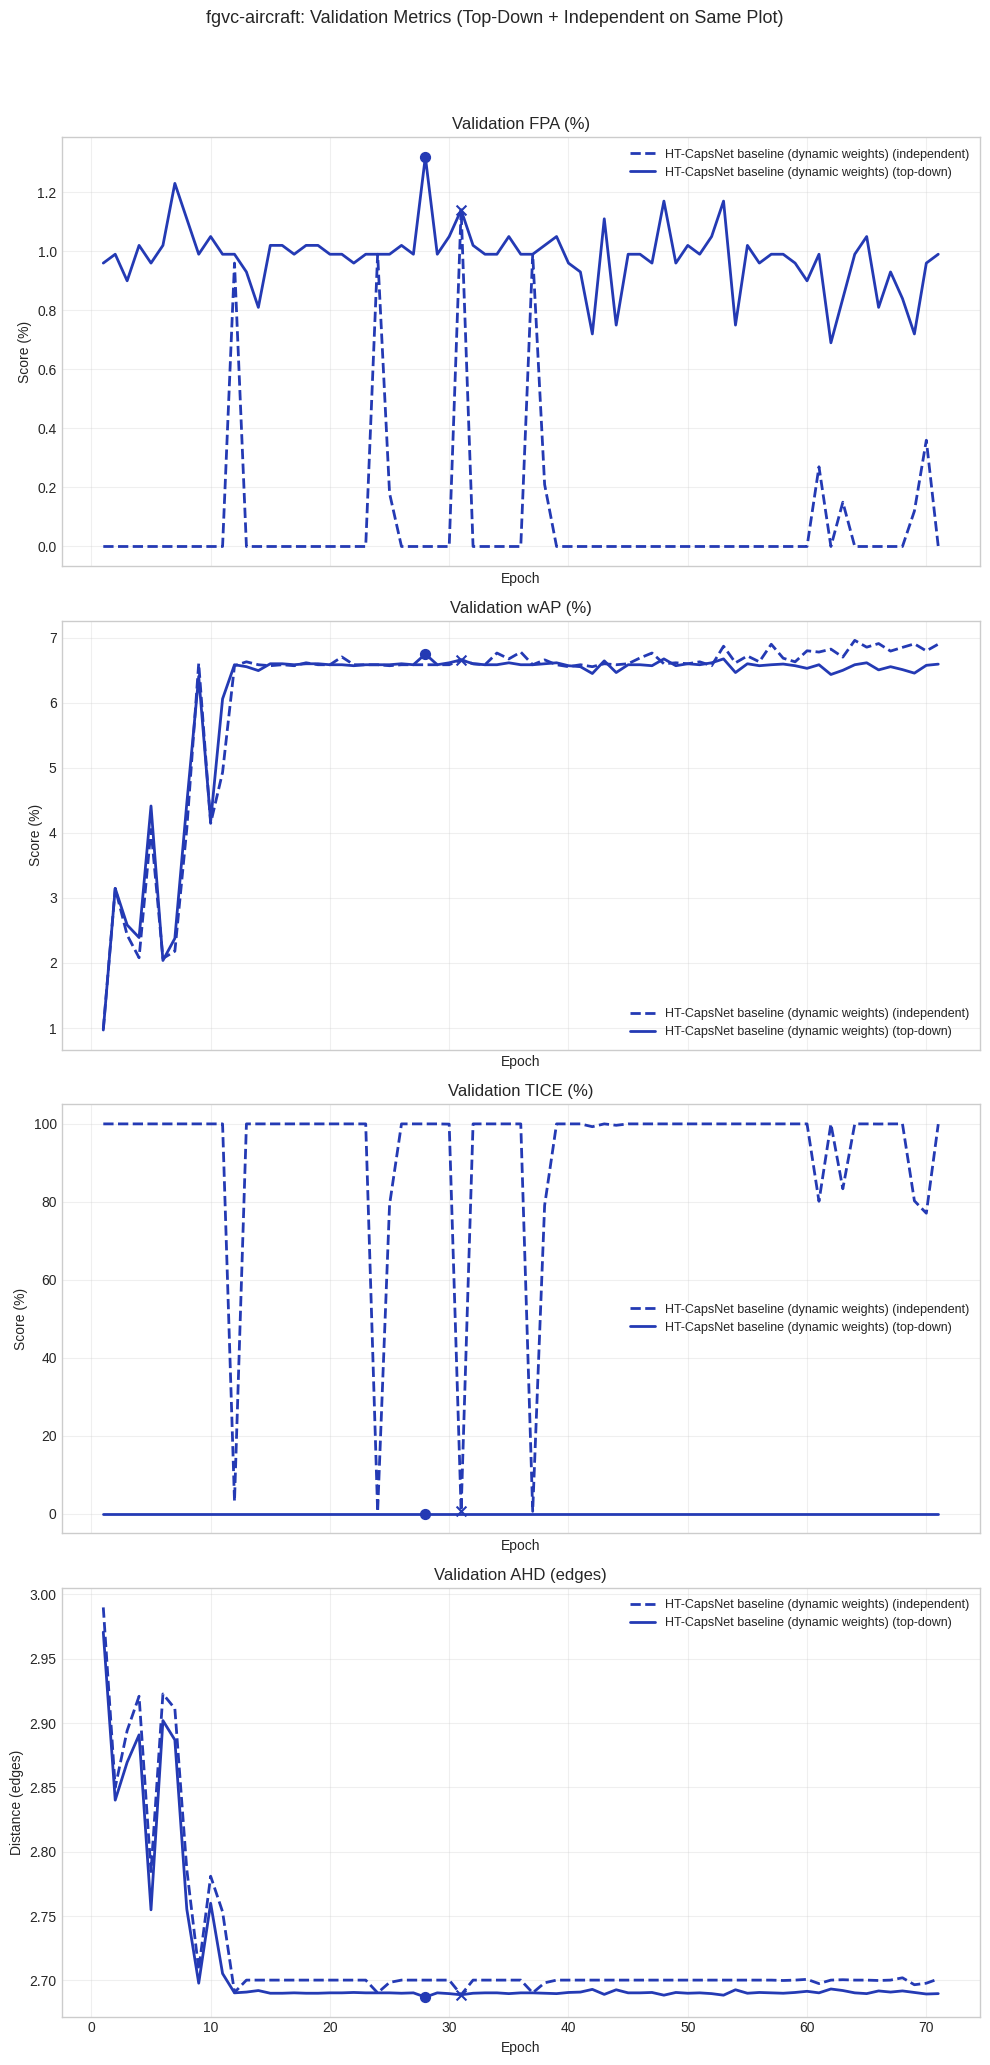

In [5]:
analysis.plot_validation_curves()

Interpretation note:

- Compare line styles of the same color to isolate decoder dependence. Top-down TICE is zero by construction and should not be presented as learned consistency.
- Compare colors only within one dataset and decoding mode. The lexicographic arm also changes the level-weighting policy, so its difference from the native baseline does not isolate gradient projection alone.
- Large uncertainty bands should be checked against the per-seed collapse screen before being described as ordinary seed variance.

## Per-Level Validation Accuracy

The coarse, middle, and fine panels retain both decoders. Capsule collapse is often easier to recognize here than in an aggregate path metric because one or more levels remain near the corresponding class-prior accuracy.

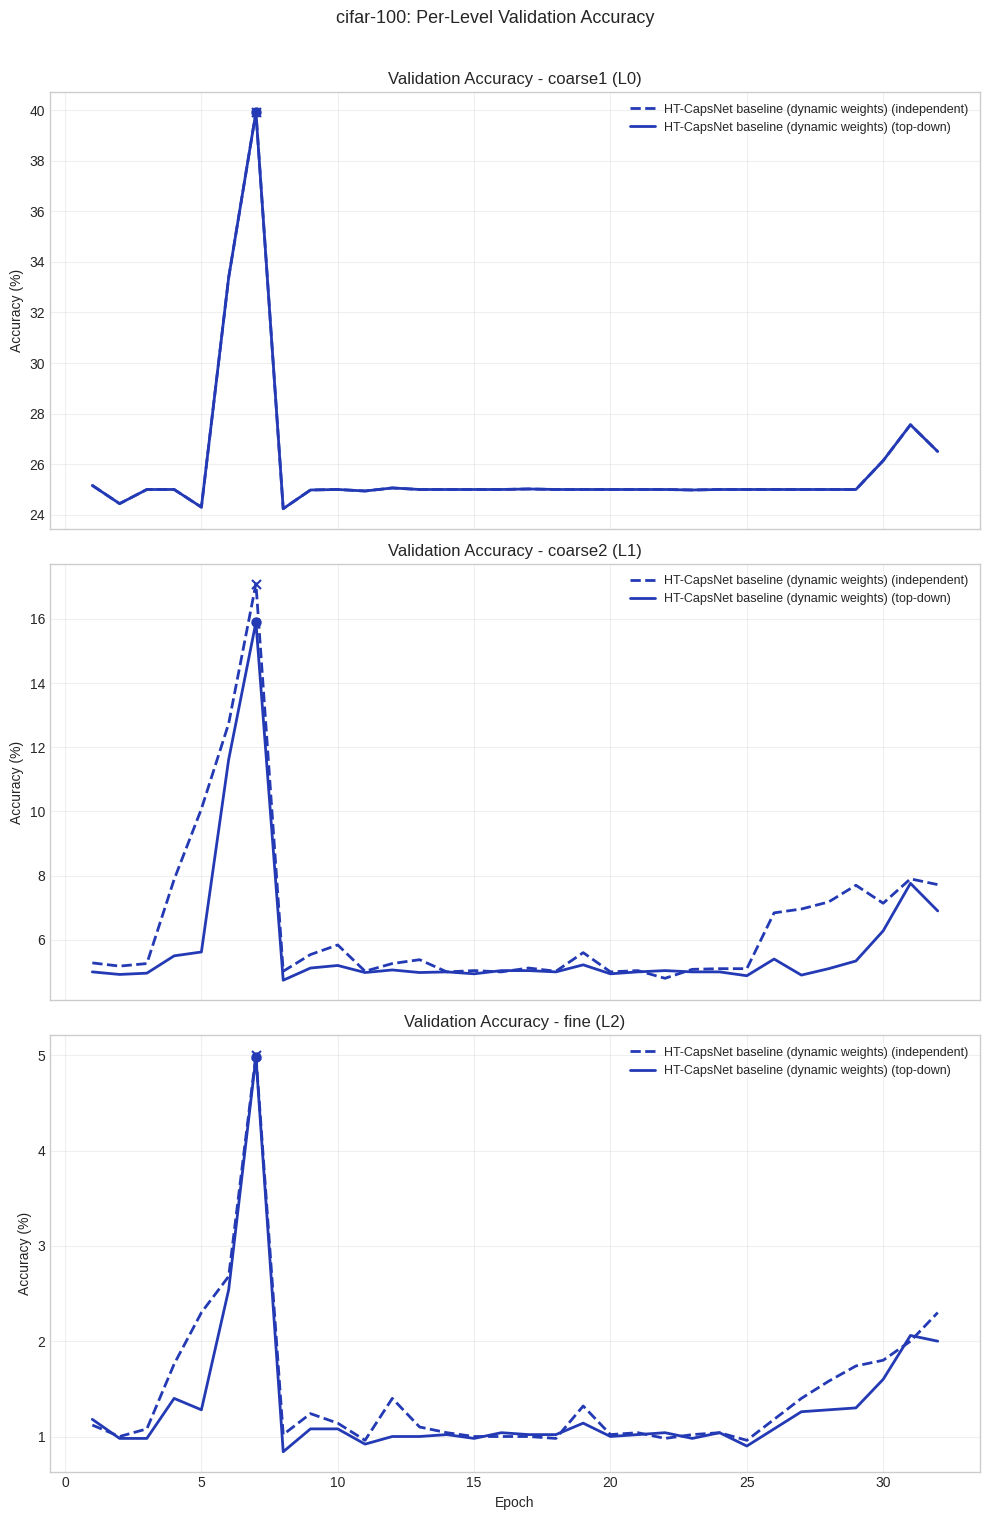

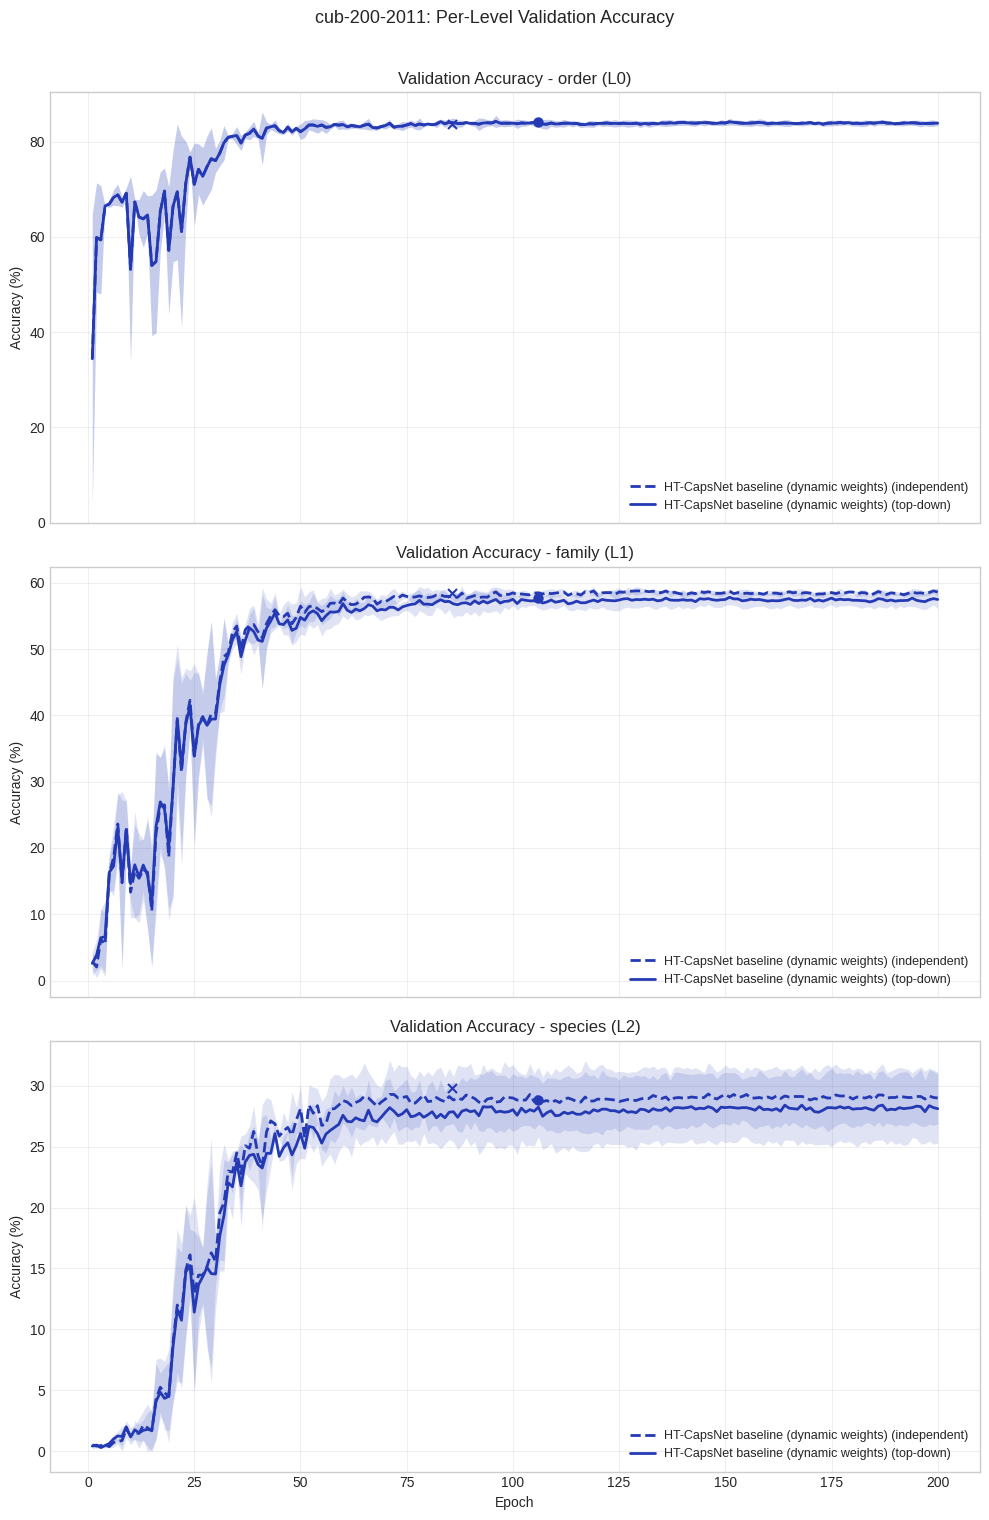

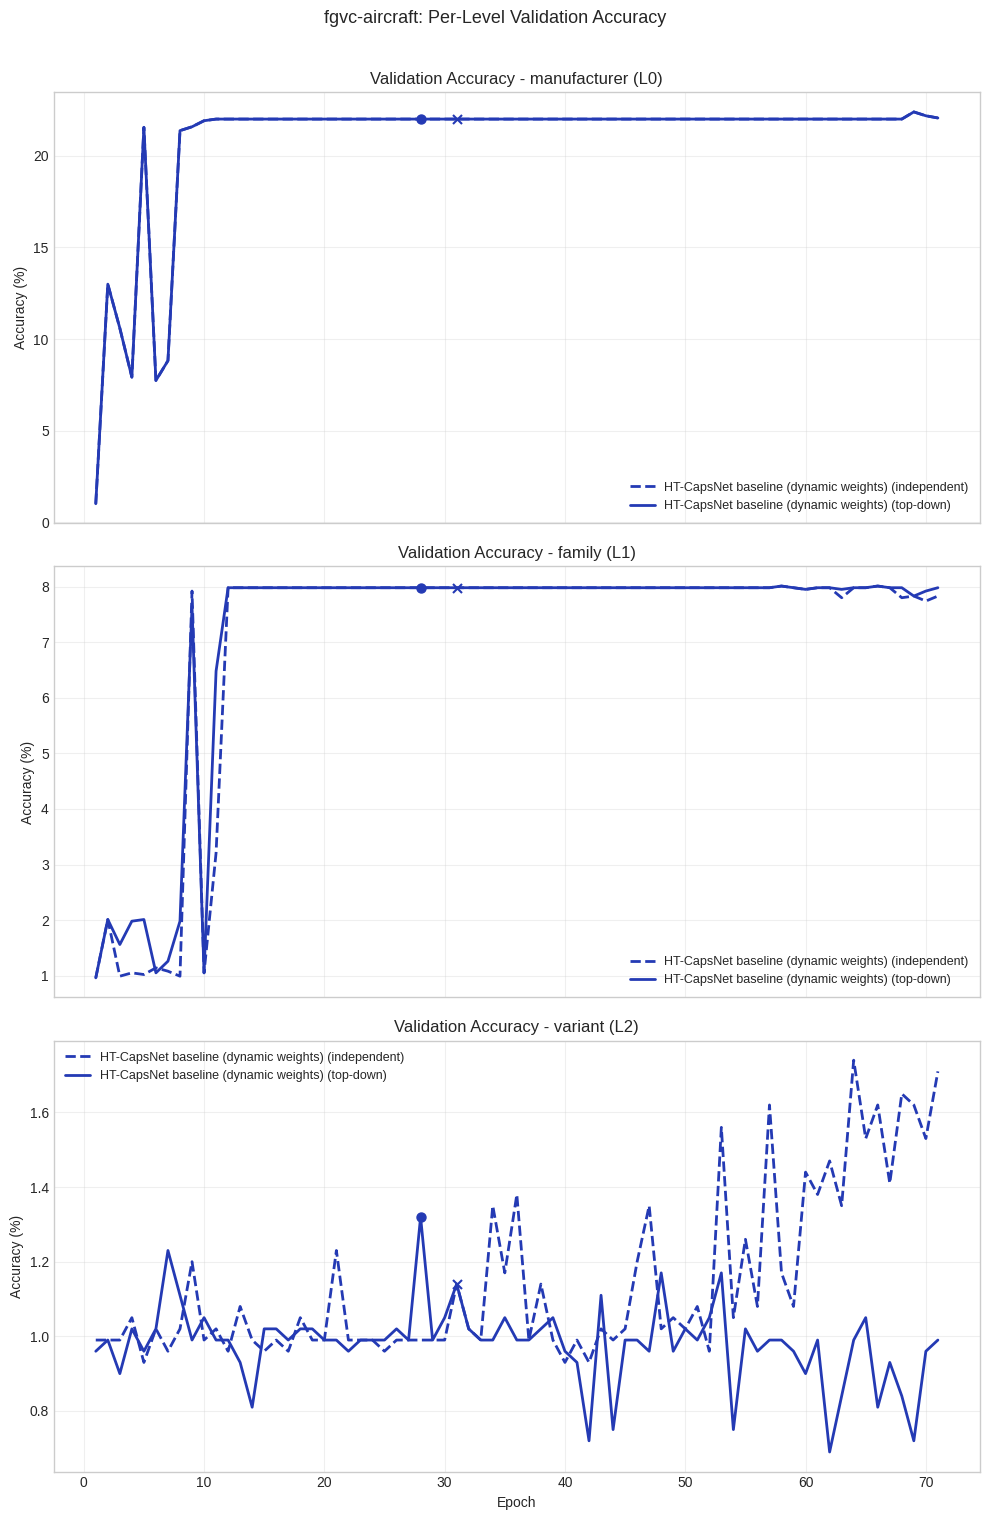

In [6]:
analysis.plot_per_level_validation_accuracy()

Interpretation note:

- Match line style when comparing training variants and match color when measuring the top-down penalty or gain.
- A strong coarse level does not imply a useful fine representation. Report all three levels when diagnosing HT-CapsNet.
- CUB and Aircraft have different class counts and hierarchy imbalance, so the absolute level accuracies are not directly comparable across datasets.

## Capsule Margin Losses

`total` and `margin` are the weighted sum of the three raw capsule margin losses. The `loss_level_*` curves are the unweighted per-level objectives exposed to explicit lexicographic training. Lower loss is not sufficient evidence of better classification because the constant-output solution can have a low, stable margin loss.

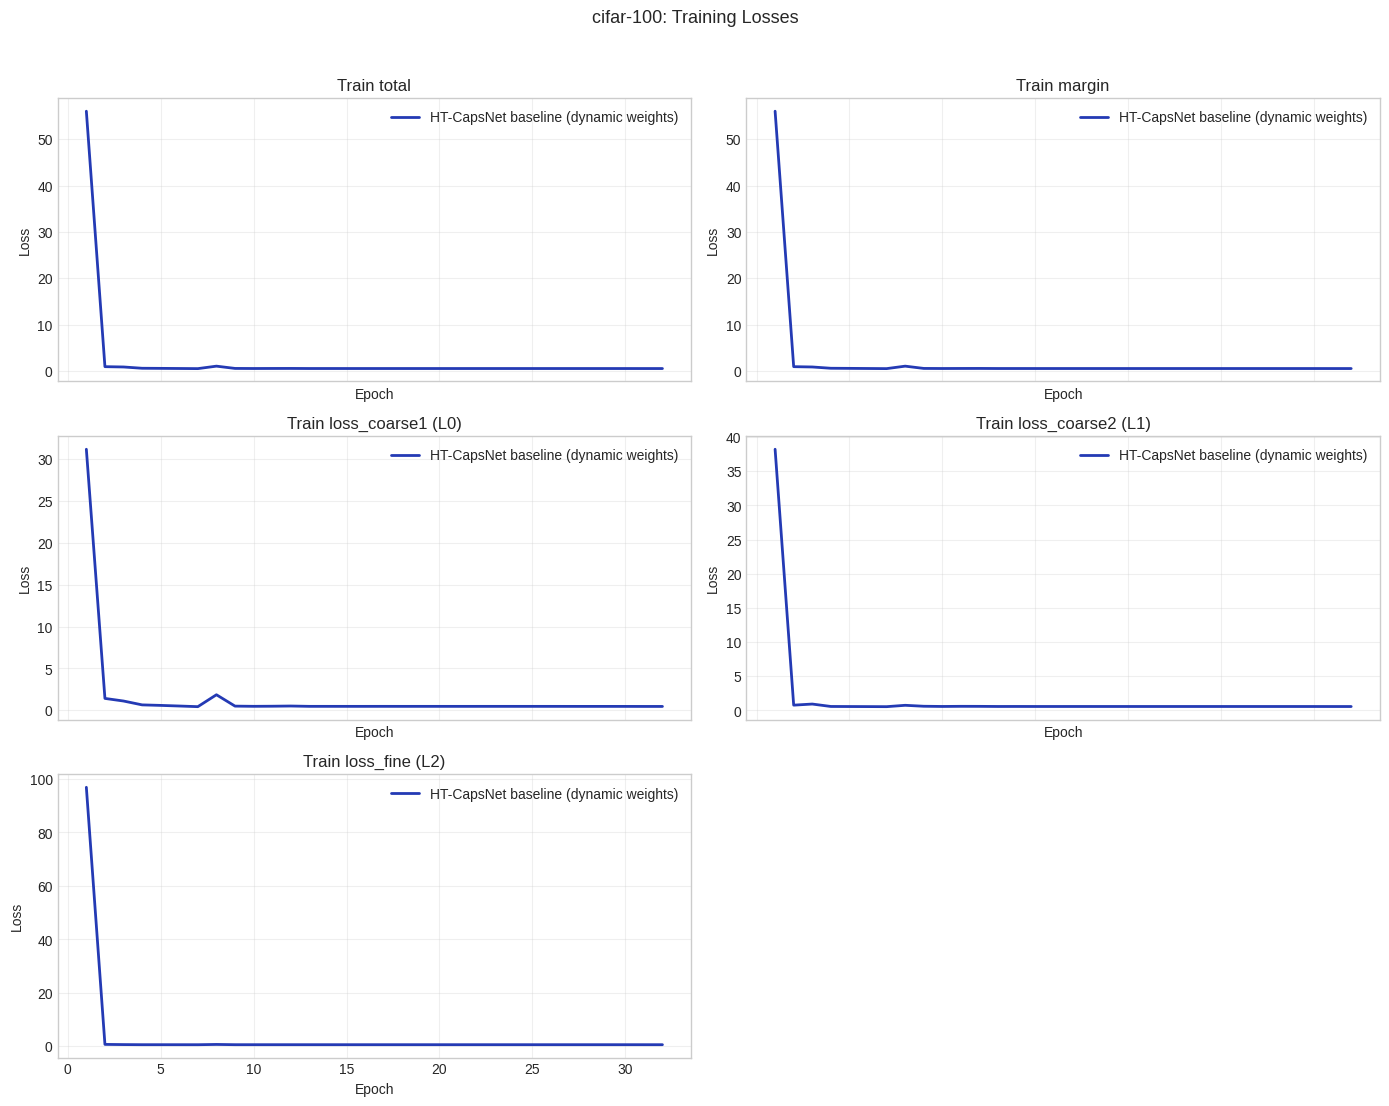

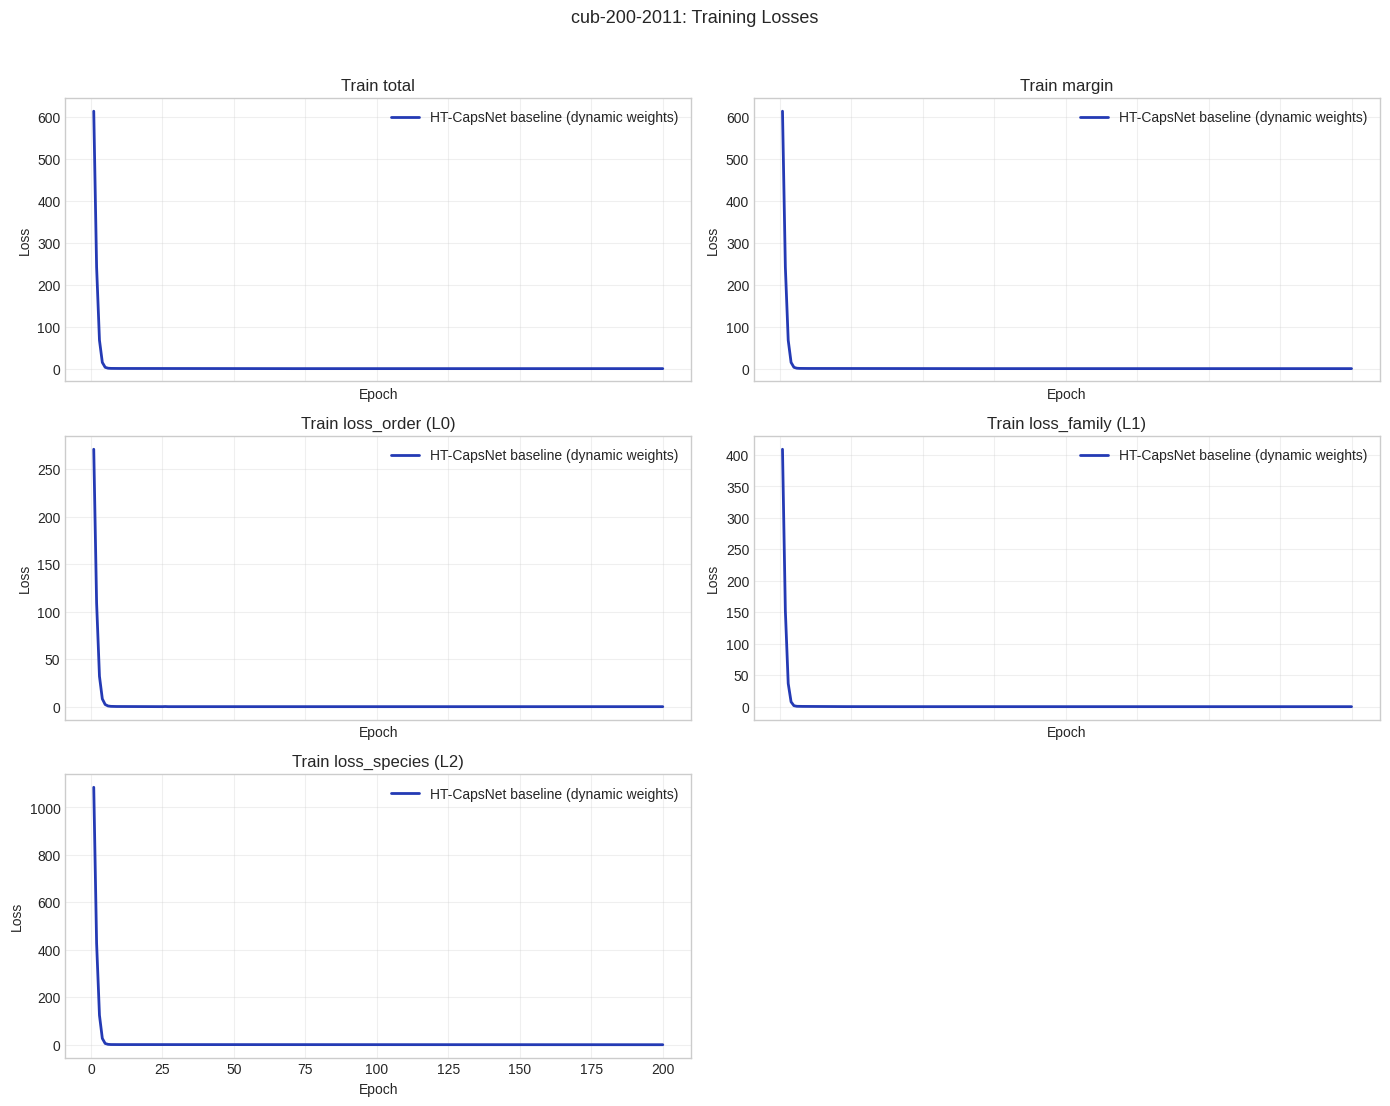

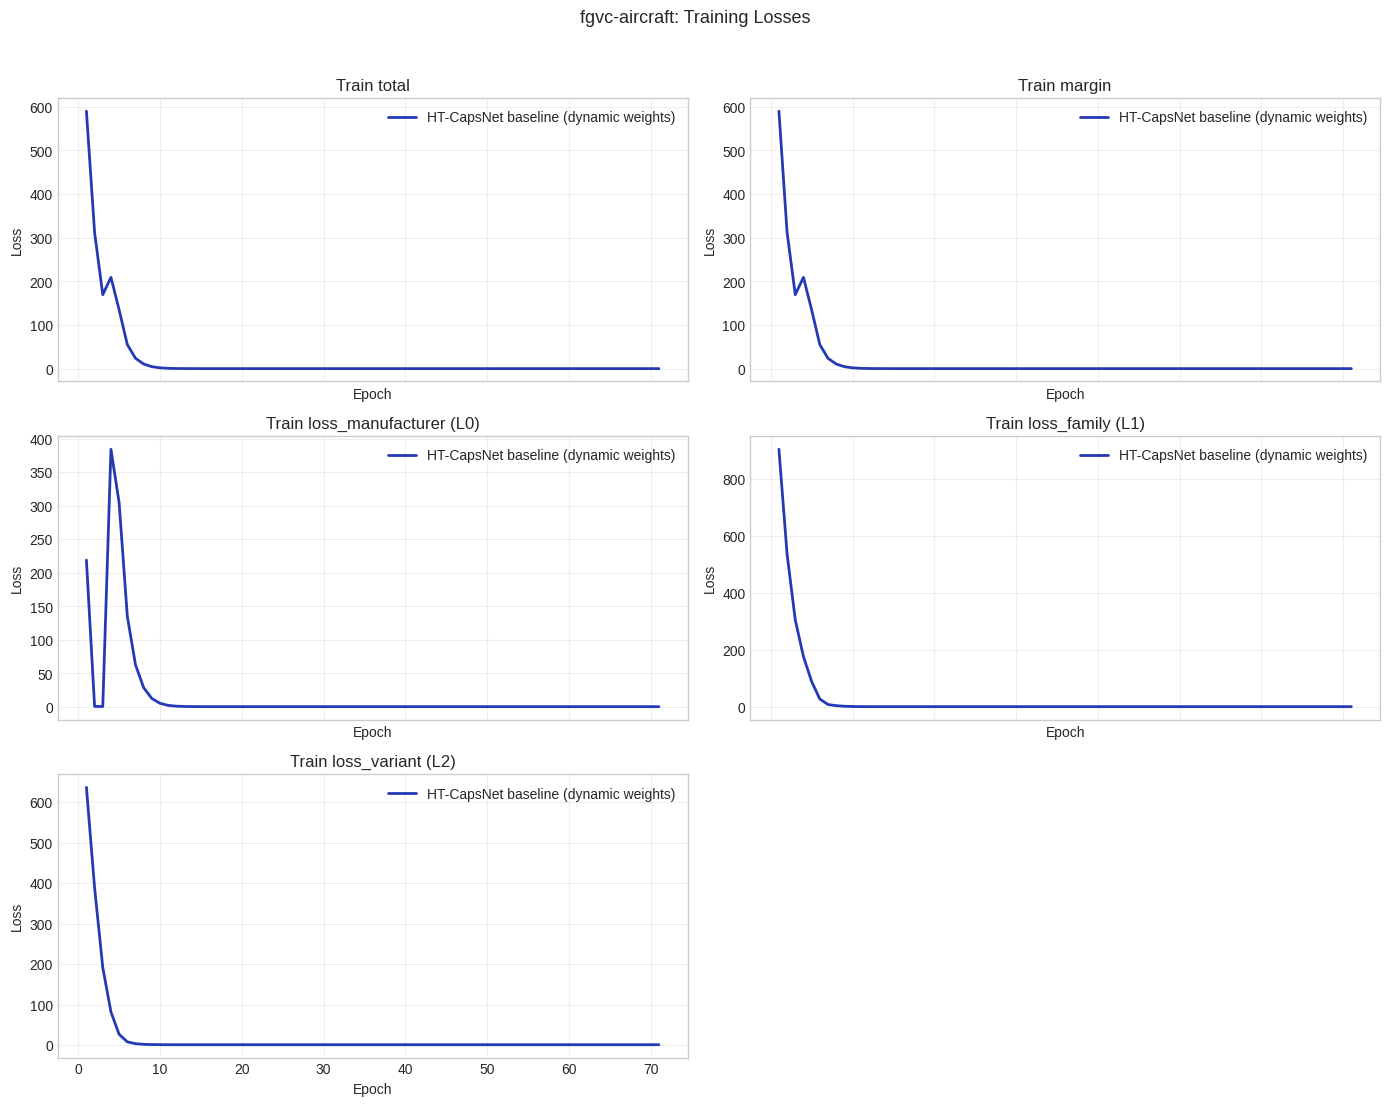

In [7]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'margin'])

## Effective Level-Loss Weights

The native baseline uses next-batch dynamic weights, whereas the lexicographic launcher sets `model.loss.weight_mode=none`, yielding unit weights. These curves make that comparison variable explicit.

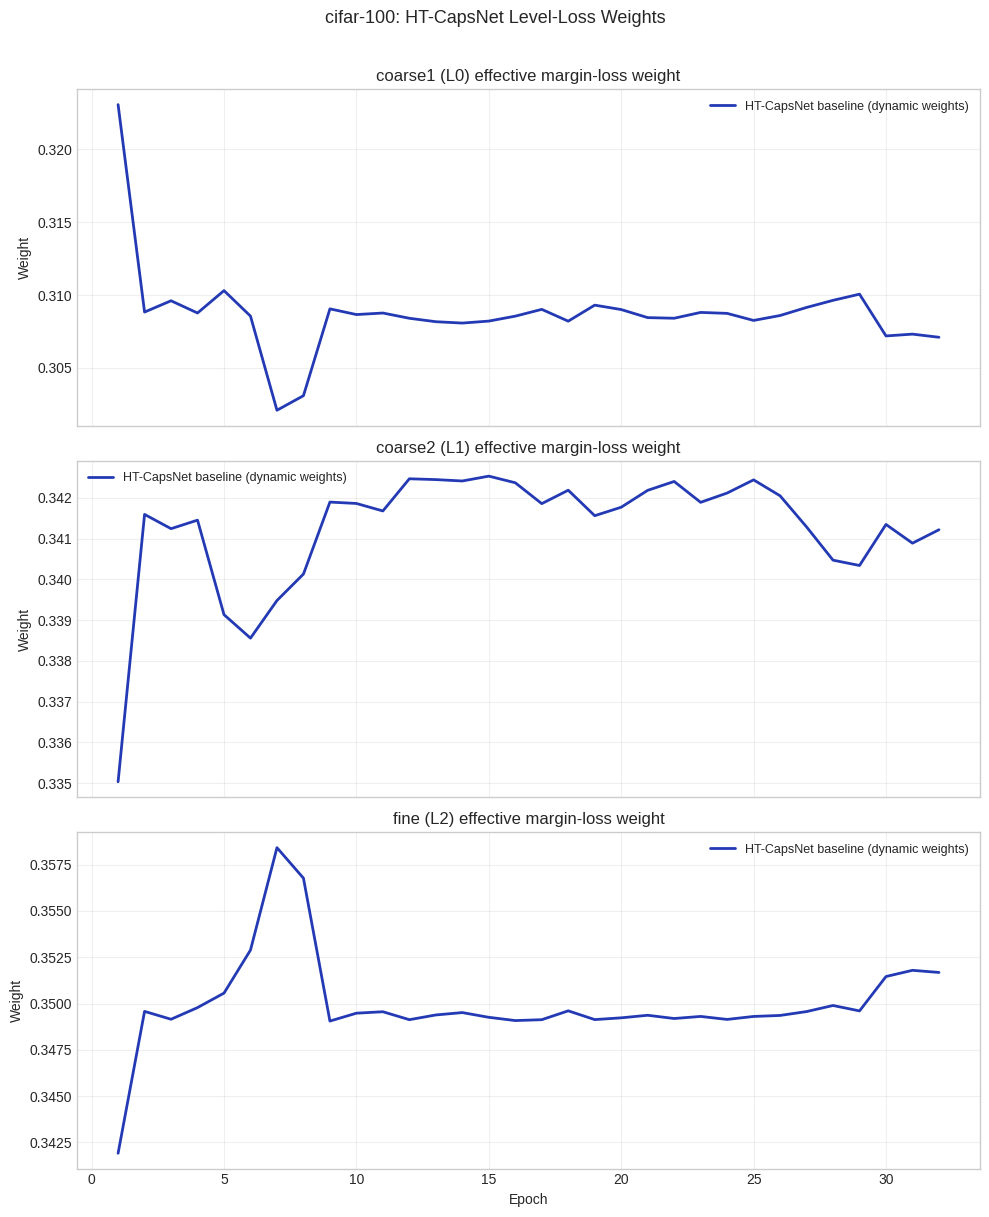

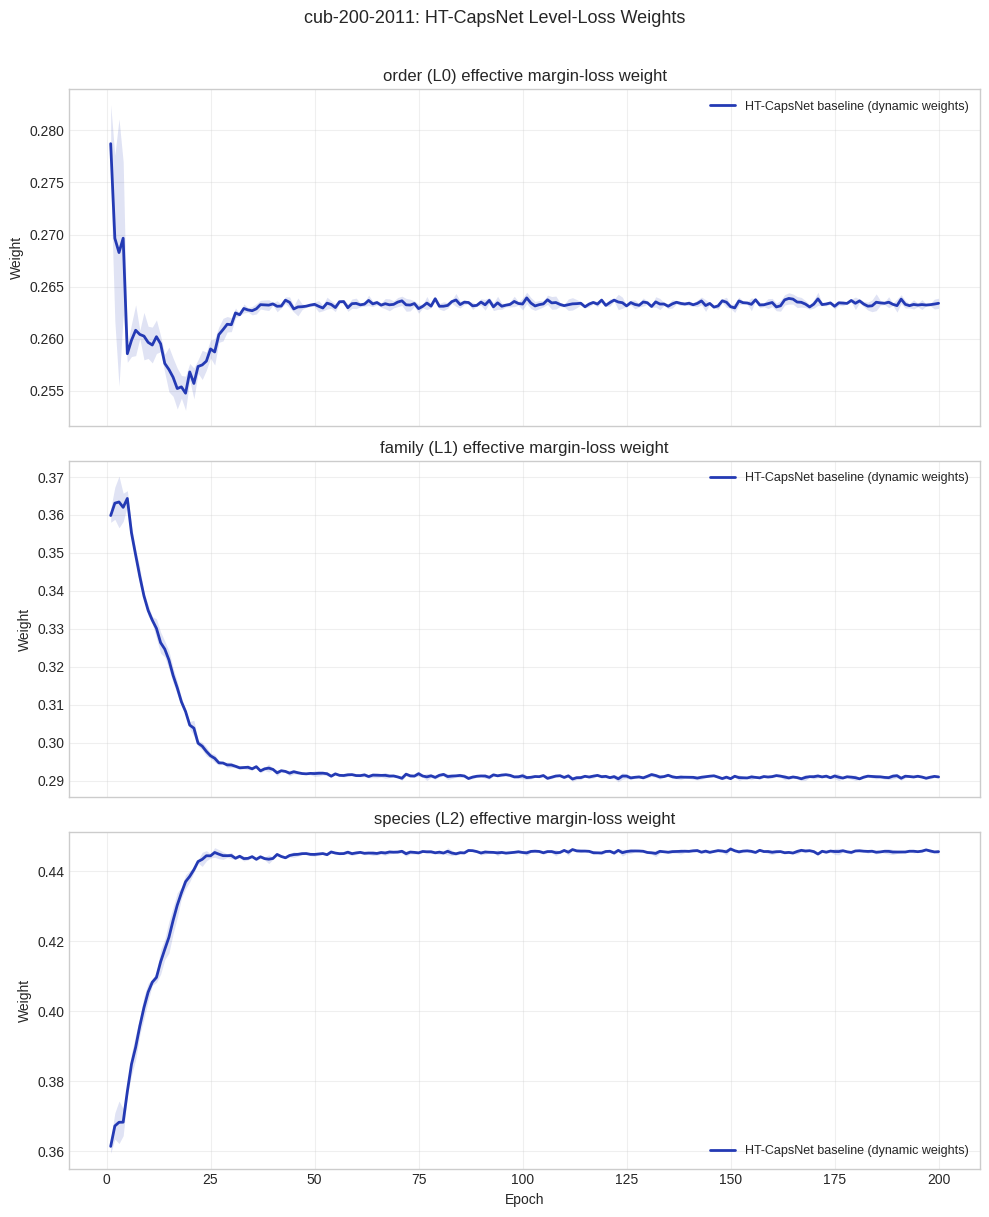

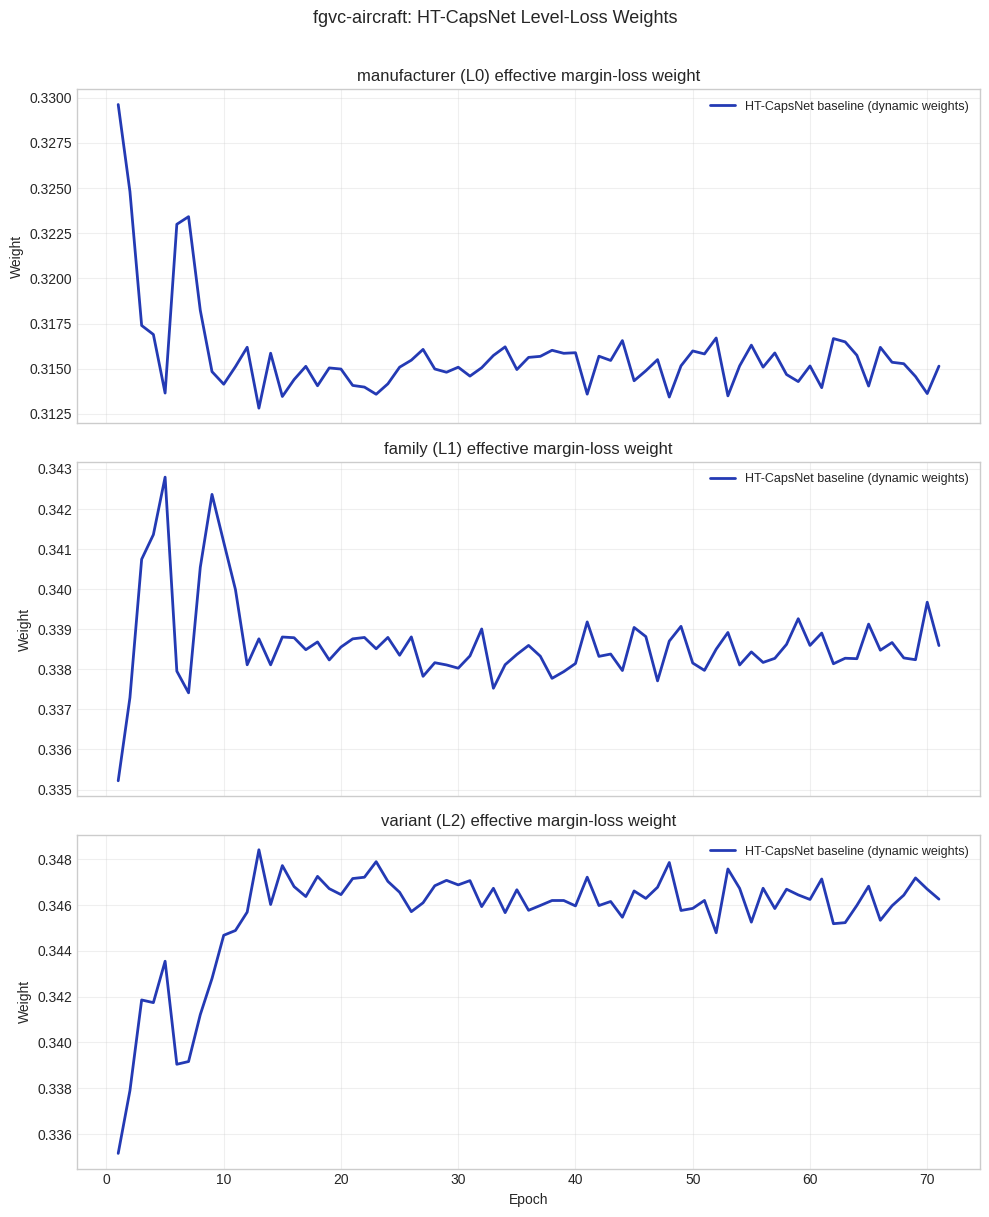

In [8]:
def plot_level_loss_weights(analysis):
    for dataset_key in analysis.dataset_keys:
        dataset_runs = analysis.run_data_by_dataset.get(dataset_key, [])
        if not dataset_runs:
            continue

        fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
        plotted_any = False
        for level, ax in enumerate(axes):
            metric_key = f'loss_weight_level_{level}'
            for run_data in dataset_runs:
                epochs, means, stds, counts = metric_series_with_std(
                    run_data['epoch_events'], metric_key, source='train_losses'
                )
                finite = np.isfinite(means)
                if not np.any(finite):
                    continue
                plotted_any = True
                ax.plot(epochs, means, color=run_data['color'], linewidth=2, label=run_data['label'])
                band = finite & np.isfinite(stds) & (counts > 1)
                if np.any(band):
                    ax.fill_between(
                        epochs, means - stds, means + stds, where=band,
                        color=run_data['color'], alpha=0.14, linewidth=0,
                    )
            level_names = dataset_runs[0].get('level_names') or []
            level_name = level_names[level] if level < len(level_names) else f'L{level}'
            ax.set_title(f'{level_name} (L{level}) effective margin-loss weight')
            ax.set_ylabel('Weight')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)

        if not plotted_any:
            plt.close(fig)
            print(f'[{dataset_key}] No level-loss weights found in selected runs.')
            continue
        axes[-1].set_xlabel('Epoch')
        plt.suptitle(f'{dataset_key}: HT-CapsNet Level-Loss Weights', y=1.01, fontsize=13)
        plt.tight_layout()
        plt.show()


plot_level_loss_weights(analysis)

## Per-Run Per-Level Margin Losses

These plots keep the three raw level objectives together for each run. Compare their terminal plateaus with the per-seed reference table rather than interpreting a lower plateau as automatically better.

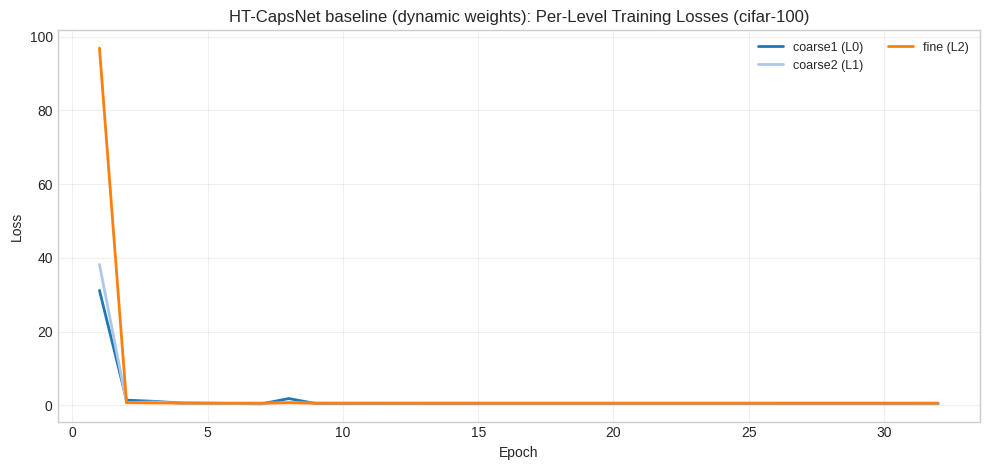

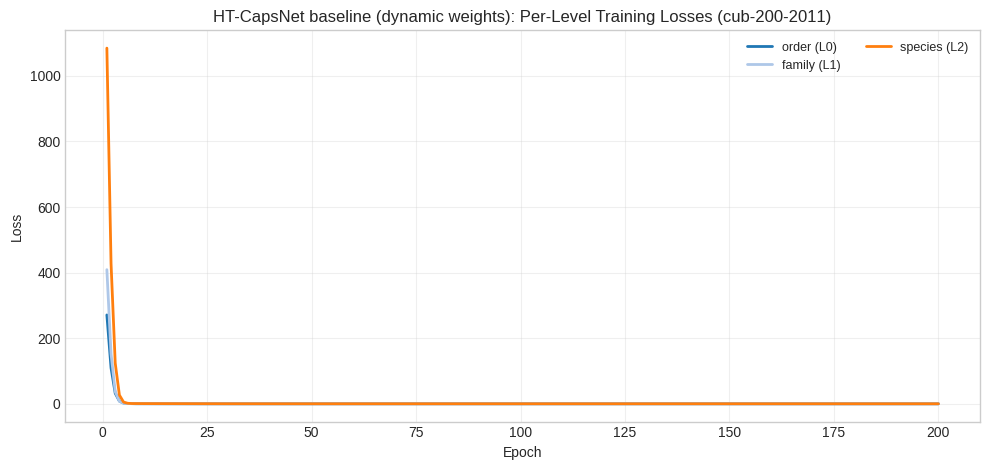

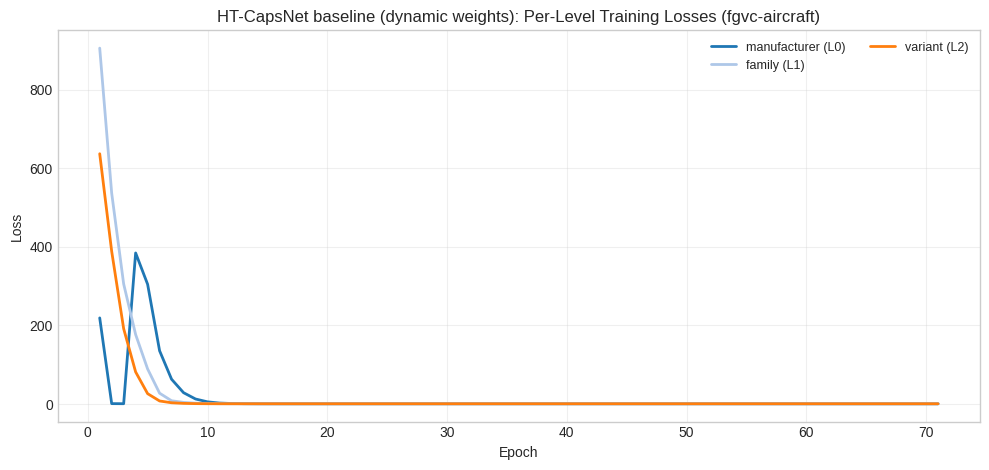

In [9]:
analysis.plot_per_run_per_level_training_losses()

## Gradient and Parameter Diagnostics

HT-CapsNet exposes three raw capsule margin objectives. Standard runs log raw shared-trunk gradient norms, pairwise cosines, parameter norms, and epoch-to-epoch parameter movement. Explicit lexicographic runs additionally log post-projection gradients, cosines, and projection-applied flags when `train.lexicographic.log_metrics=true`.

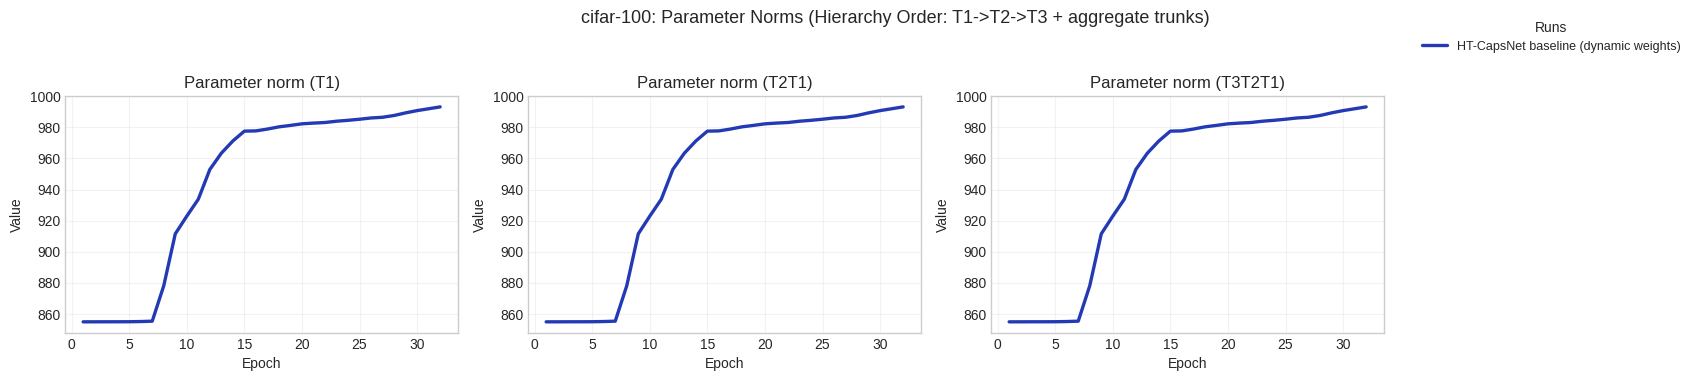

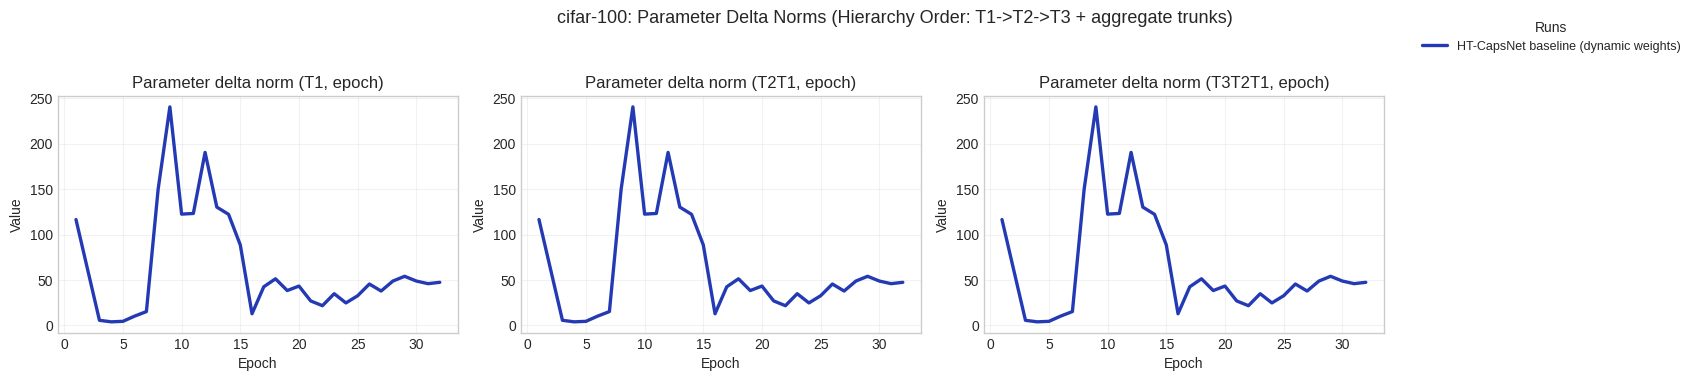

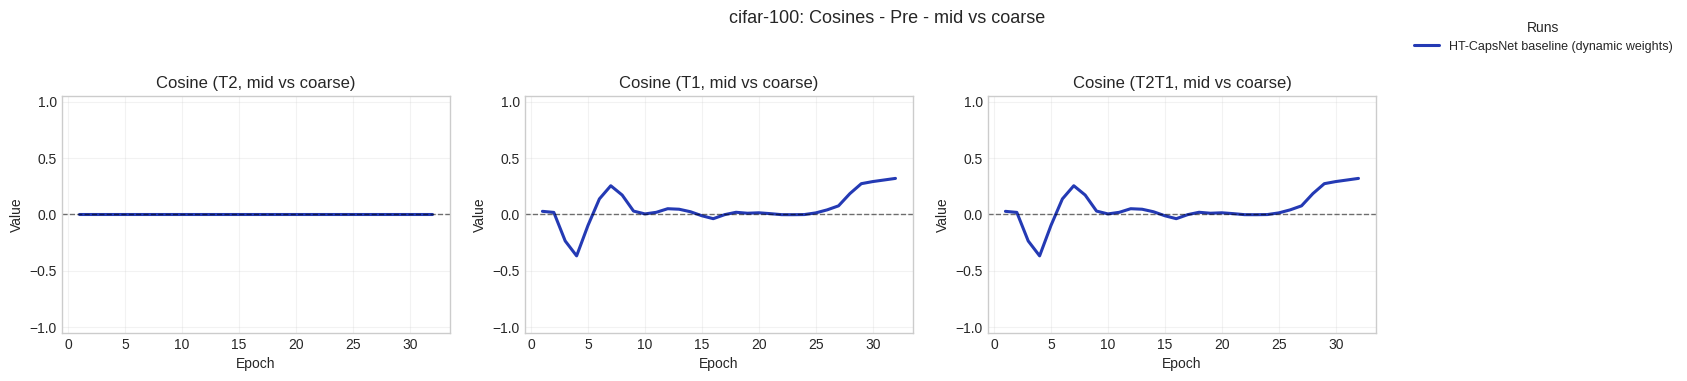

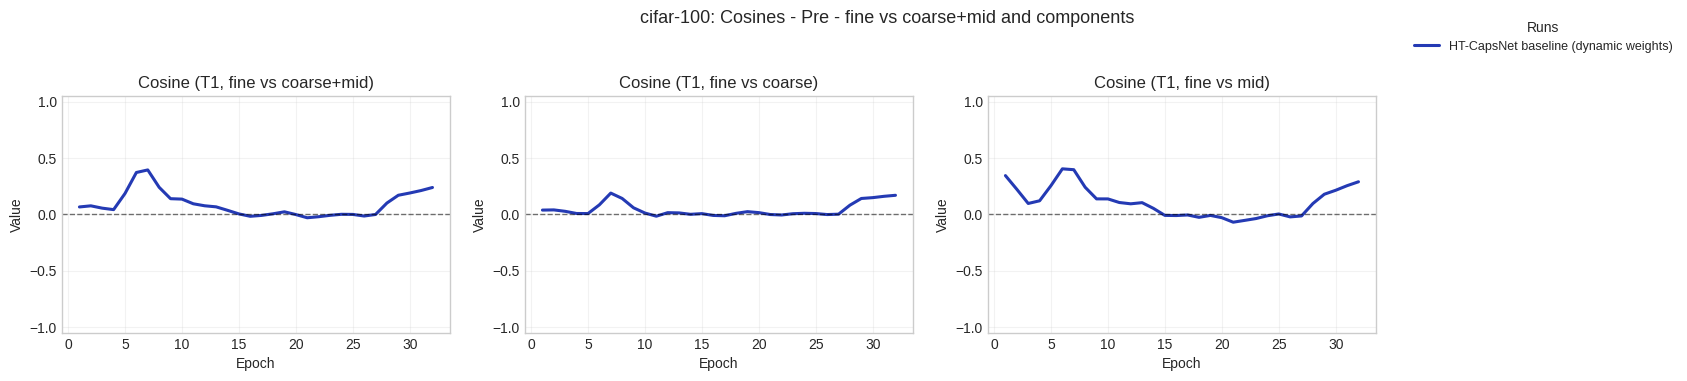

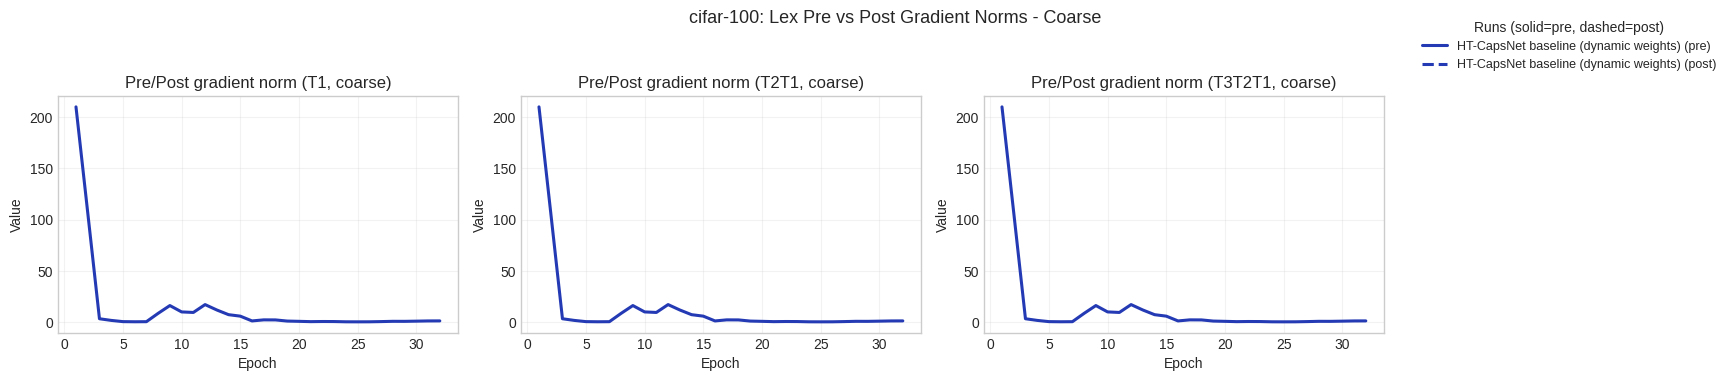

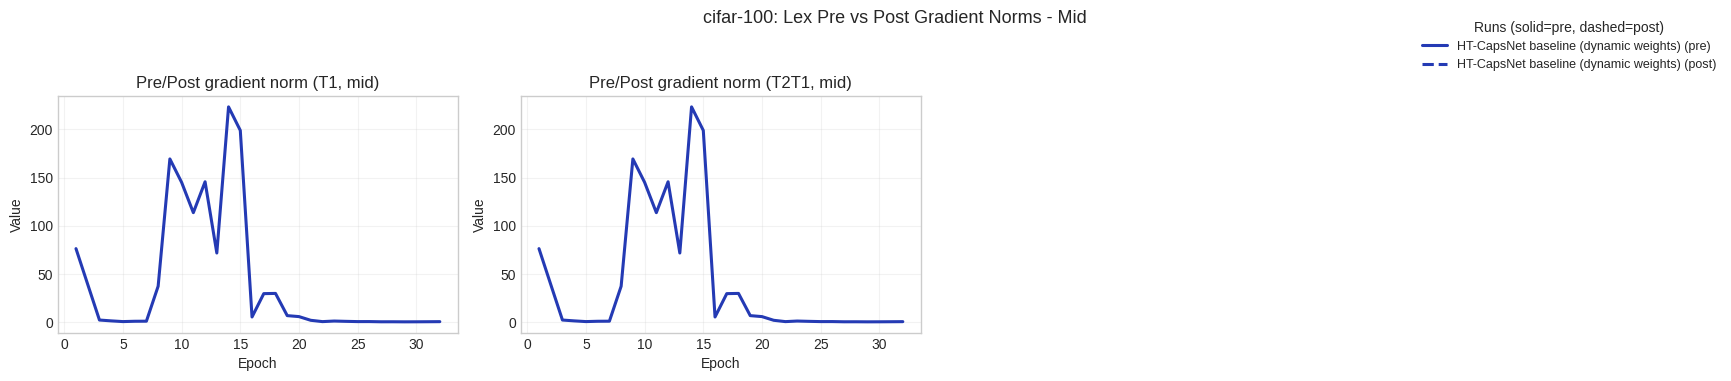

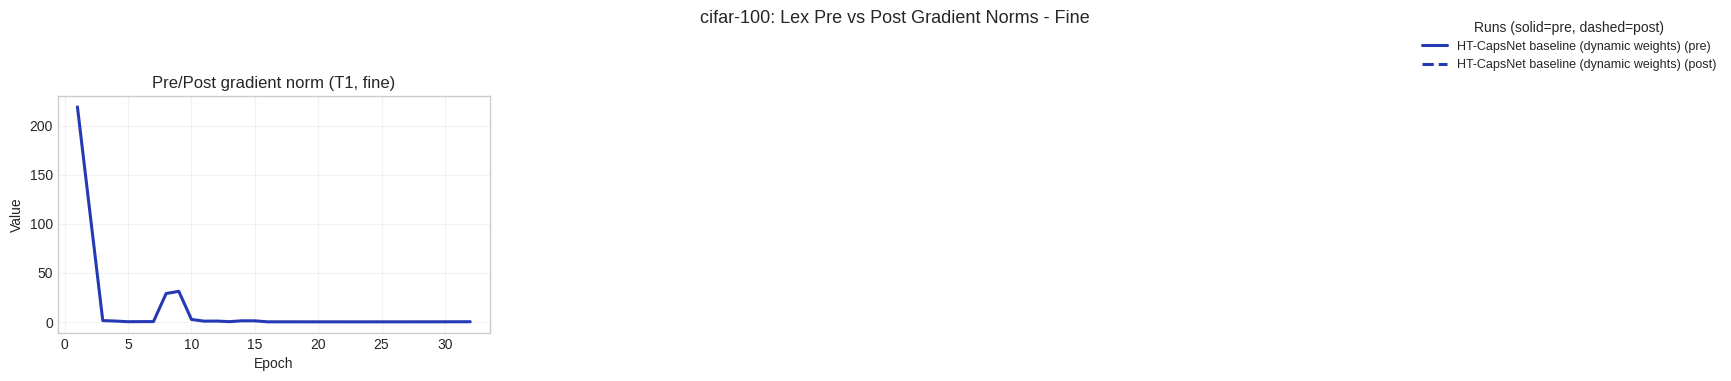

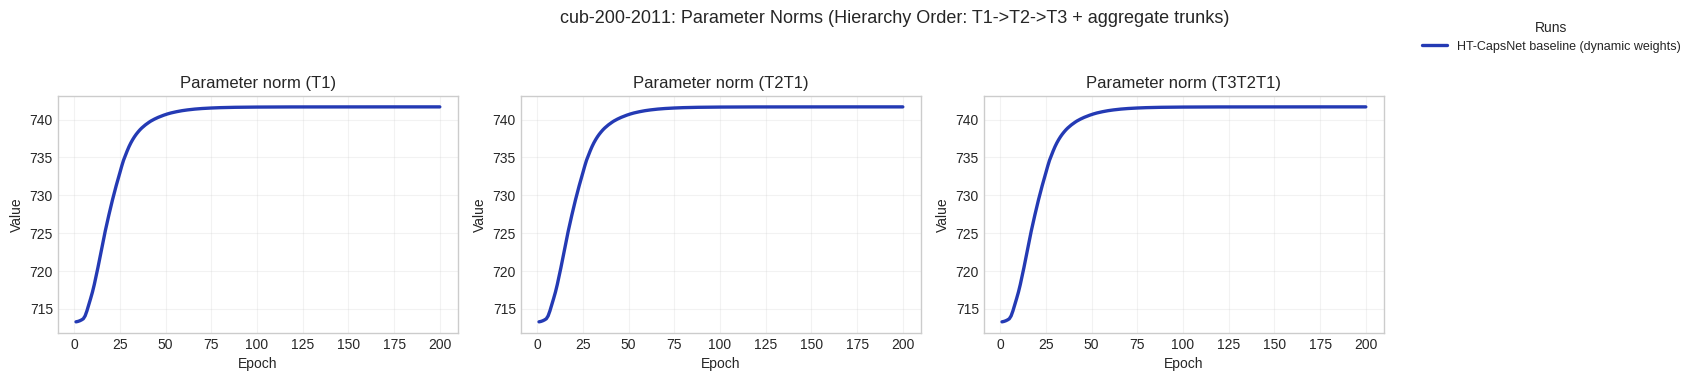

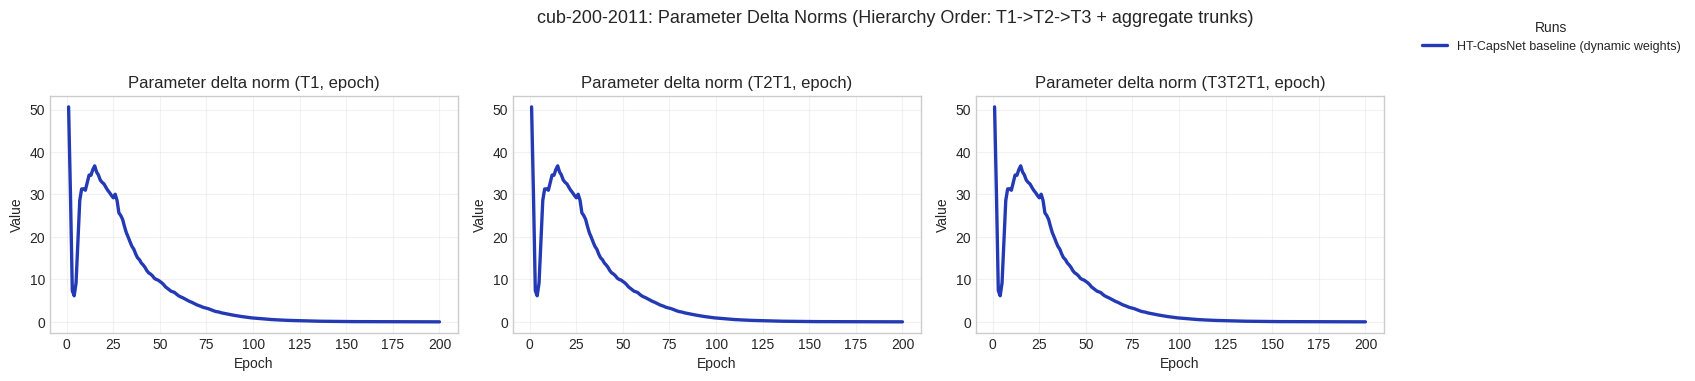

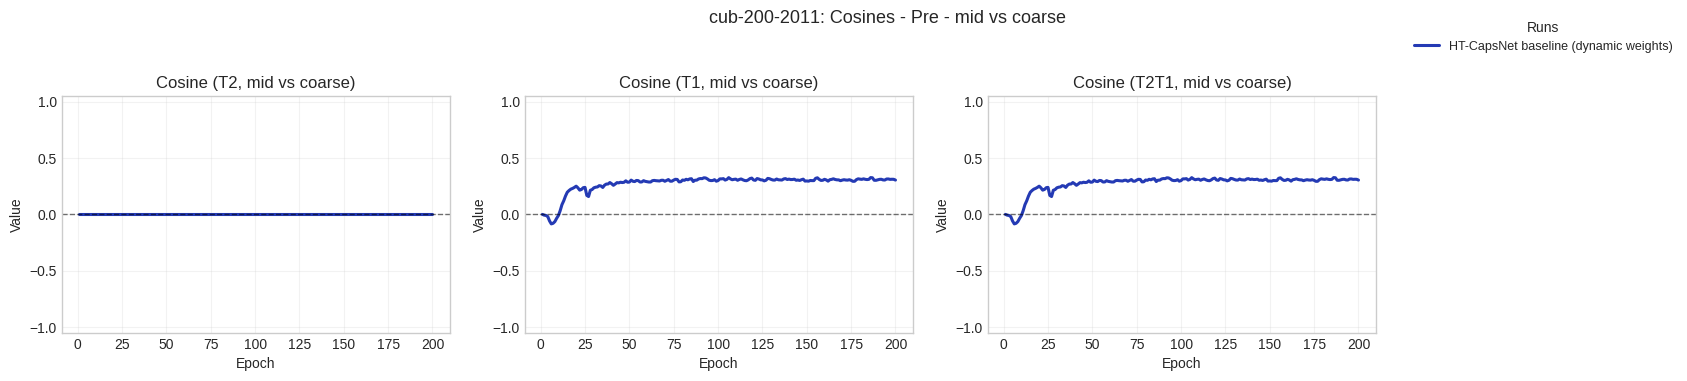

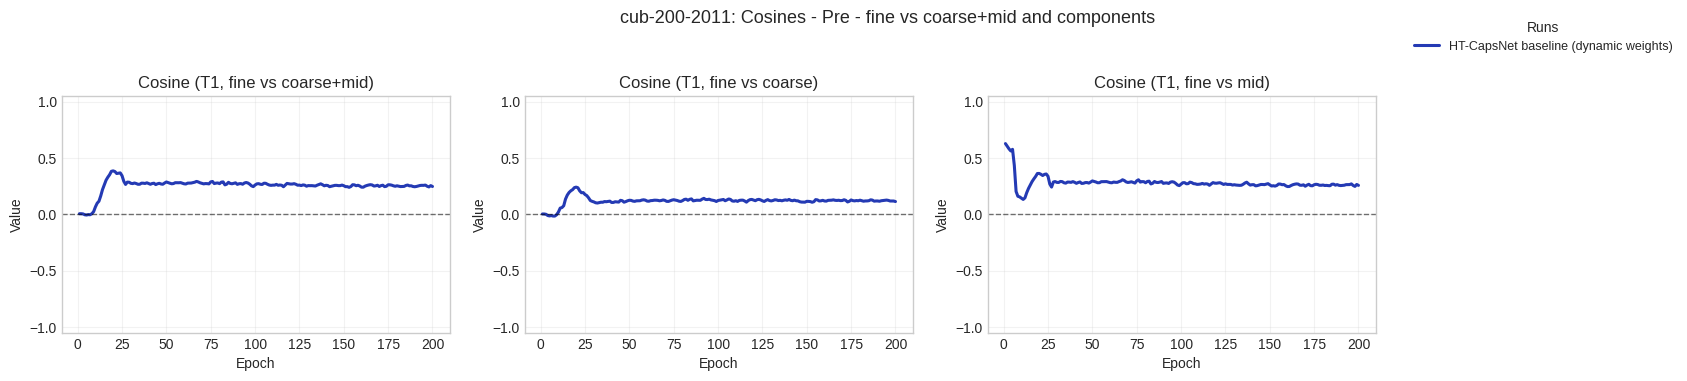

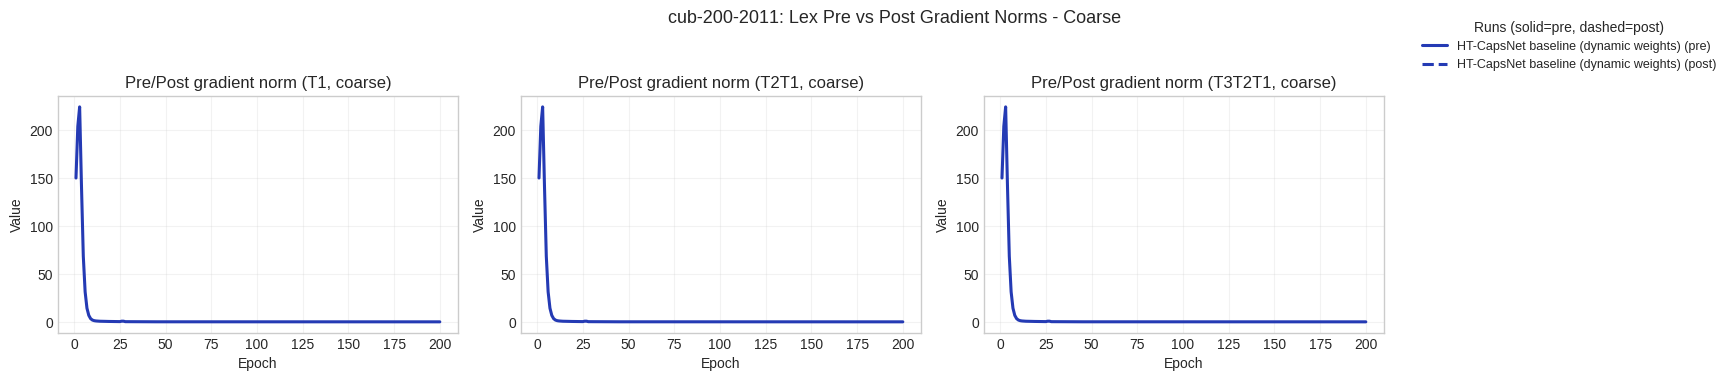

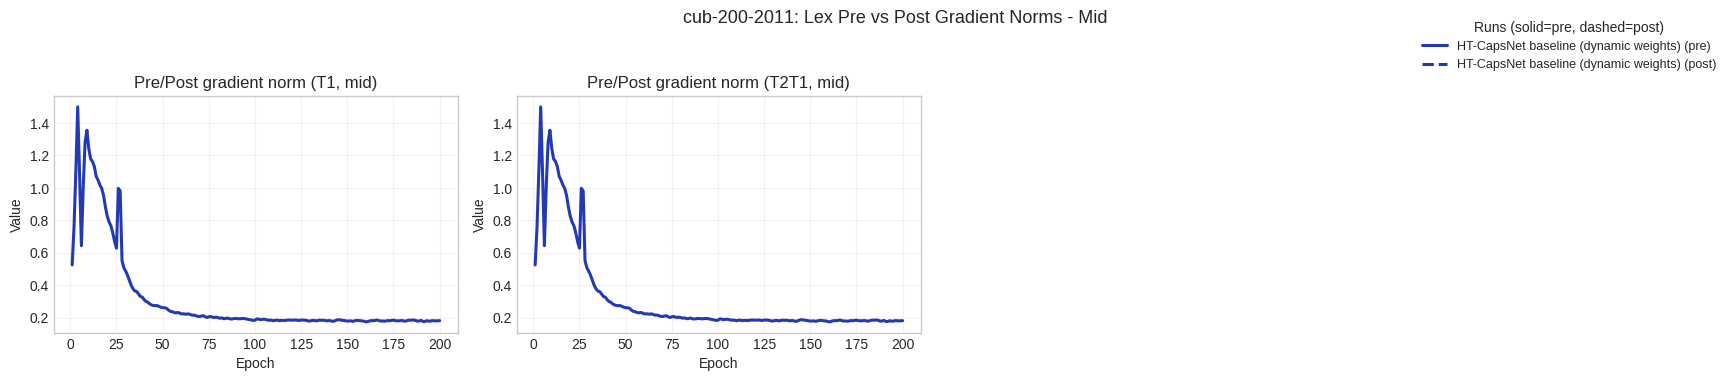

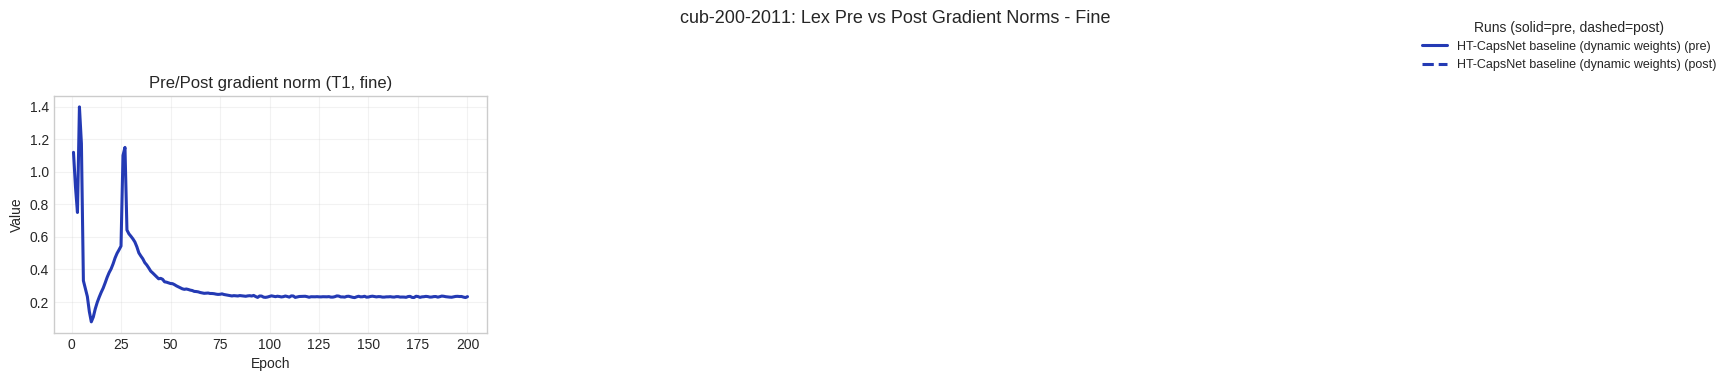

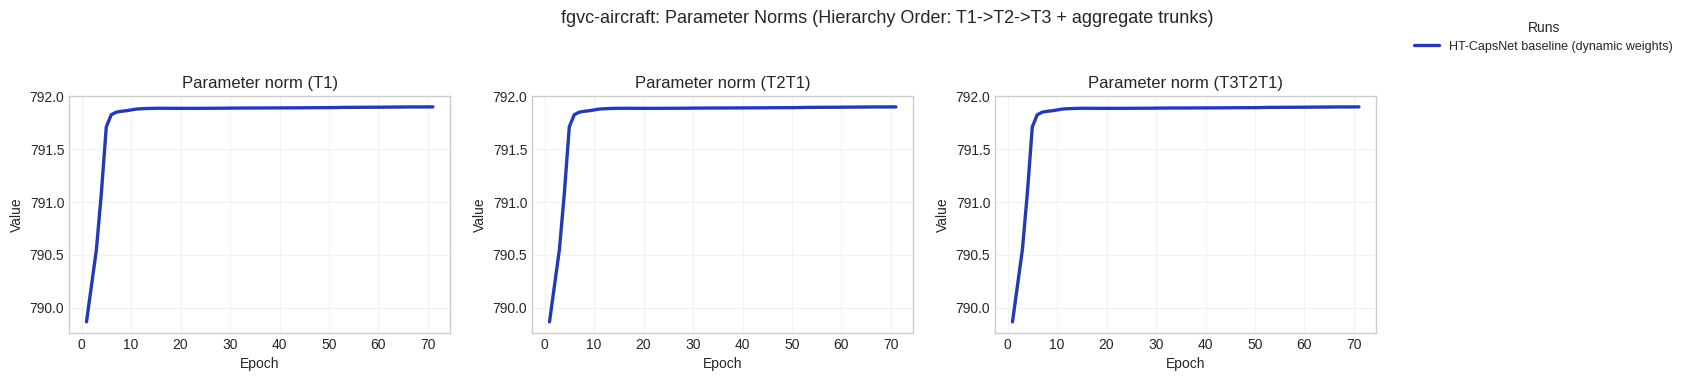

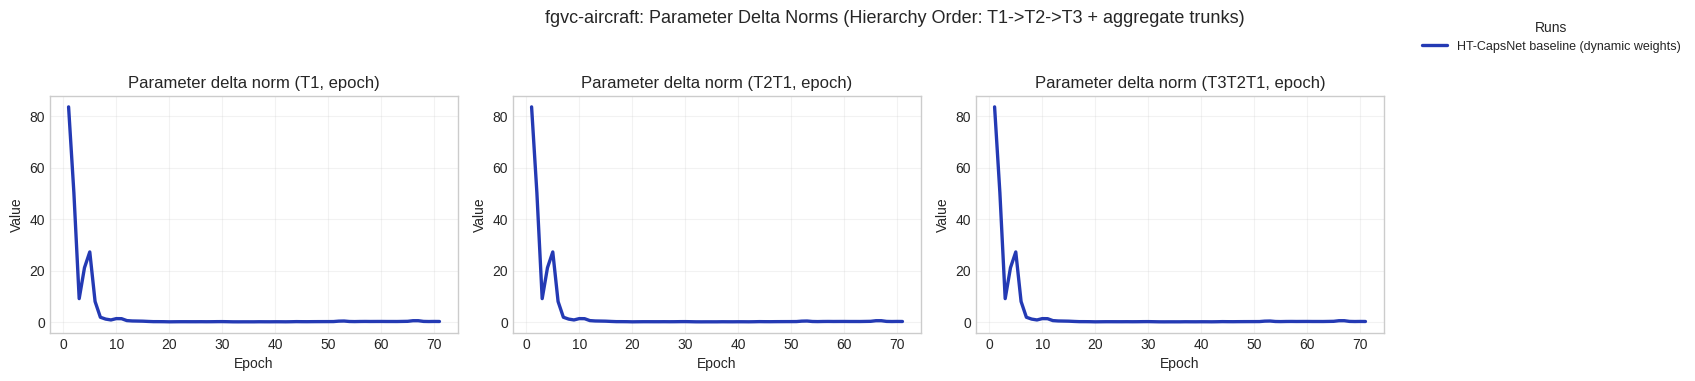

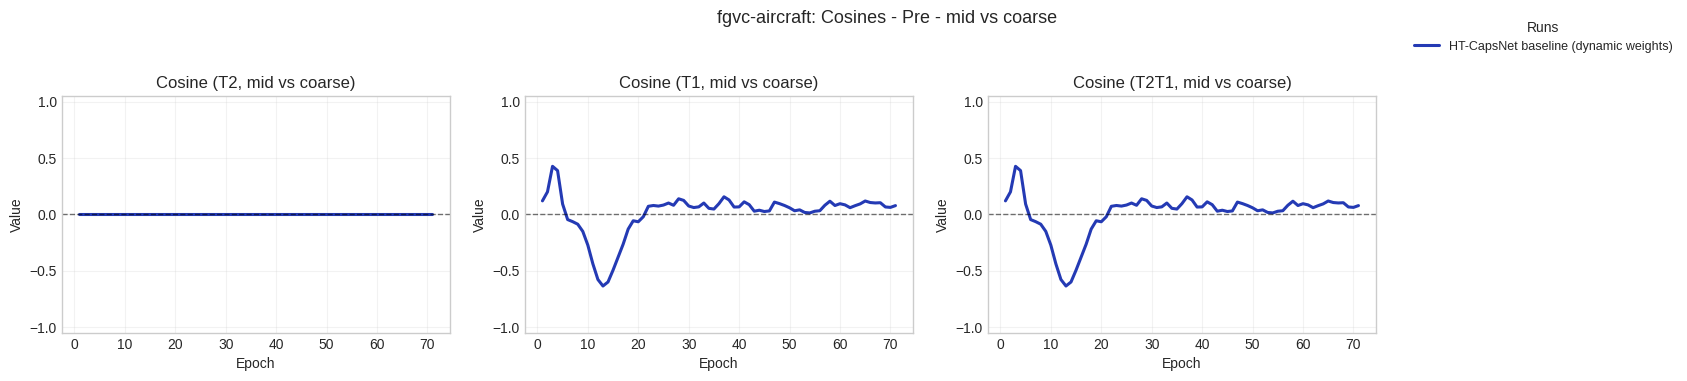

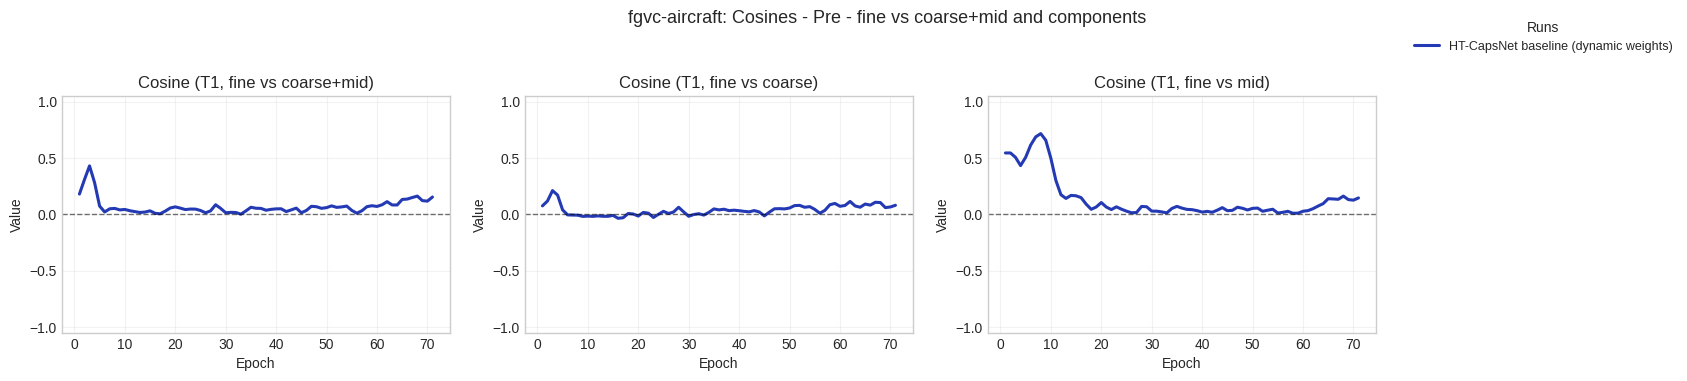

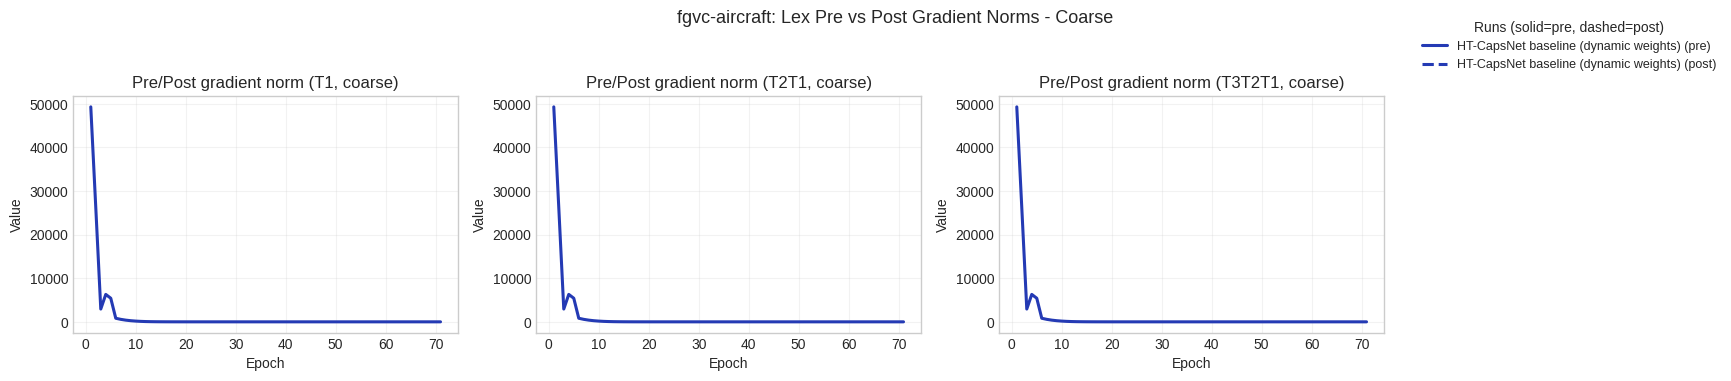

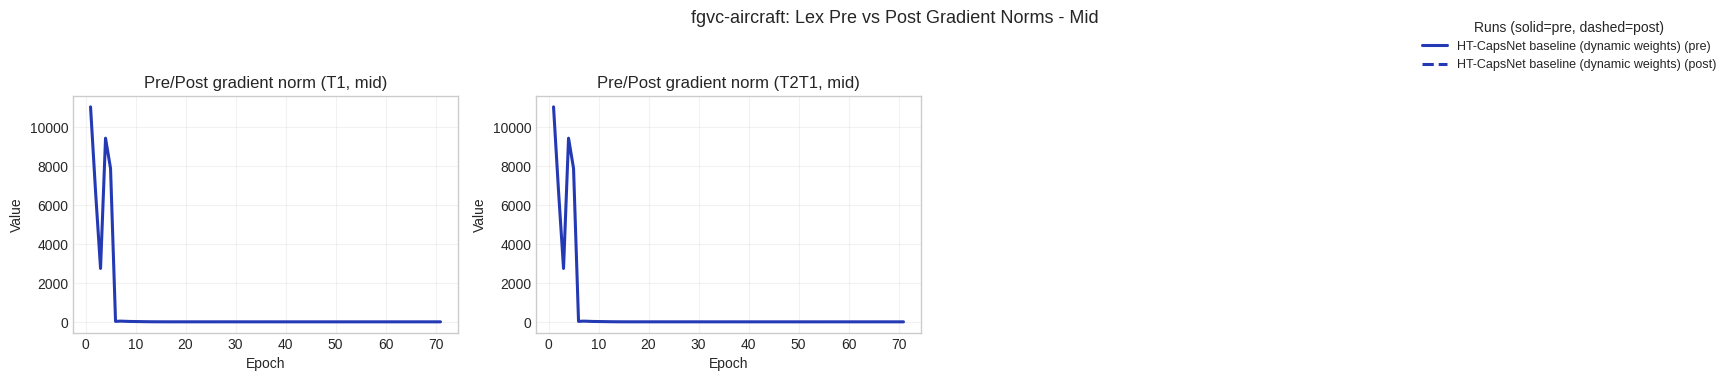

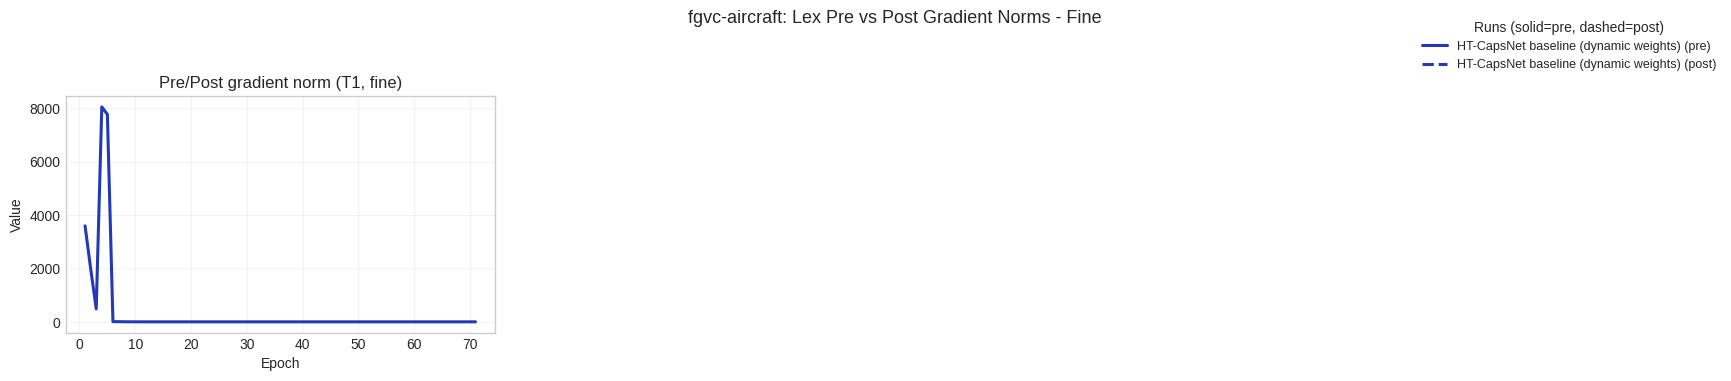

In [10]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)

Interpretation note:

- Negative raw cosines indicate objective conflict on the corresponding shared subset; positive cosines indicate alignment.
- In orthogonalize-all lex runs, the targeted post-projection cosines should move near zero when the projection-applied flag is one.
- `delta_param_norm_t1` is particularly useful beside the margin-collapse screen: a very small value shows little epoch-level shared-parameter movement, but it is not independently a collapse criterion.
- HCC is an output-space constraint. Its diagnostics below must not be described as explicit gradient-space lexicographic optimization.

## Exploratory HCC Diagnostics

HT-CapsNet's class scores are capsule lengths used by the margin loss, not unconstrained classifier logits. HCC applies an affine logit-space correction that can move these values outside the range for which the capsule margin objective was designed. Treat this arm as an exploratory compatibility ablation.

`proj_constraint_alpha=1` in the logs is the authoritative evidence that HCC was active; a directory name is not sufficient. The first block checks activation and constraint residuals.

In [11]:
analysis.plot_projection_diagnostics(
    base_diag_specs=[
        ('proj_constraint_alpha', 'HCC activation flag', False, 'val'),
        ('proj_logit_residual_before_l1', 'Constraint residual before projection', False, 'val'),
        ('proj_logit_residual_after_l1', 'Constraint residual after projection', False, 'val'),
        ('proj_logit_residual_reduction', 'Constraint residual reduction', False, 'val'),
        ('proj_logit_delta_l1_level_2', 'Fine-level absolute logit shift', False, 'val'),
        ('proj_gt_logit_delta_level_2', 'Ground-truth fine logit shift', False, 'val'),
    ]
)

[cifar-100] No projection diagnostics found in selected runs.
[cub-200-2011] No projection diagnostics found in selected runs.
[fgvc-aircraft] No projection diagnostics found in selected runs.


The second block checks whether the HCC rewrite changes the fine prediction, moves probability mass into the correct parent subtree, or worsens the ground-truth child's rank among its siblings.

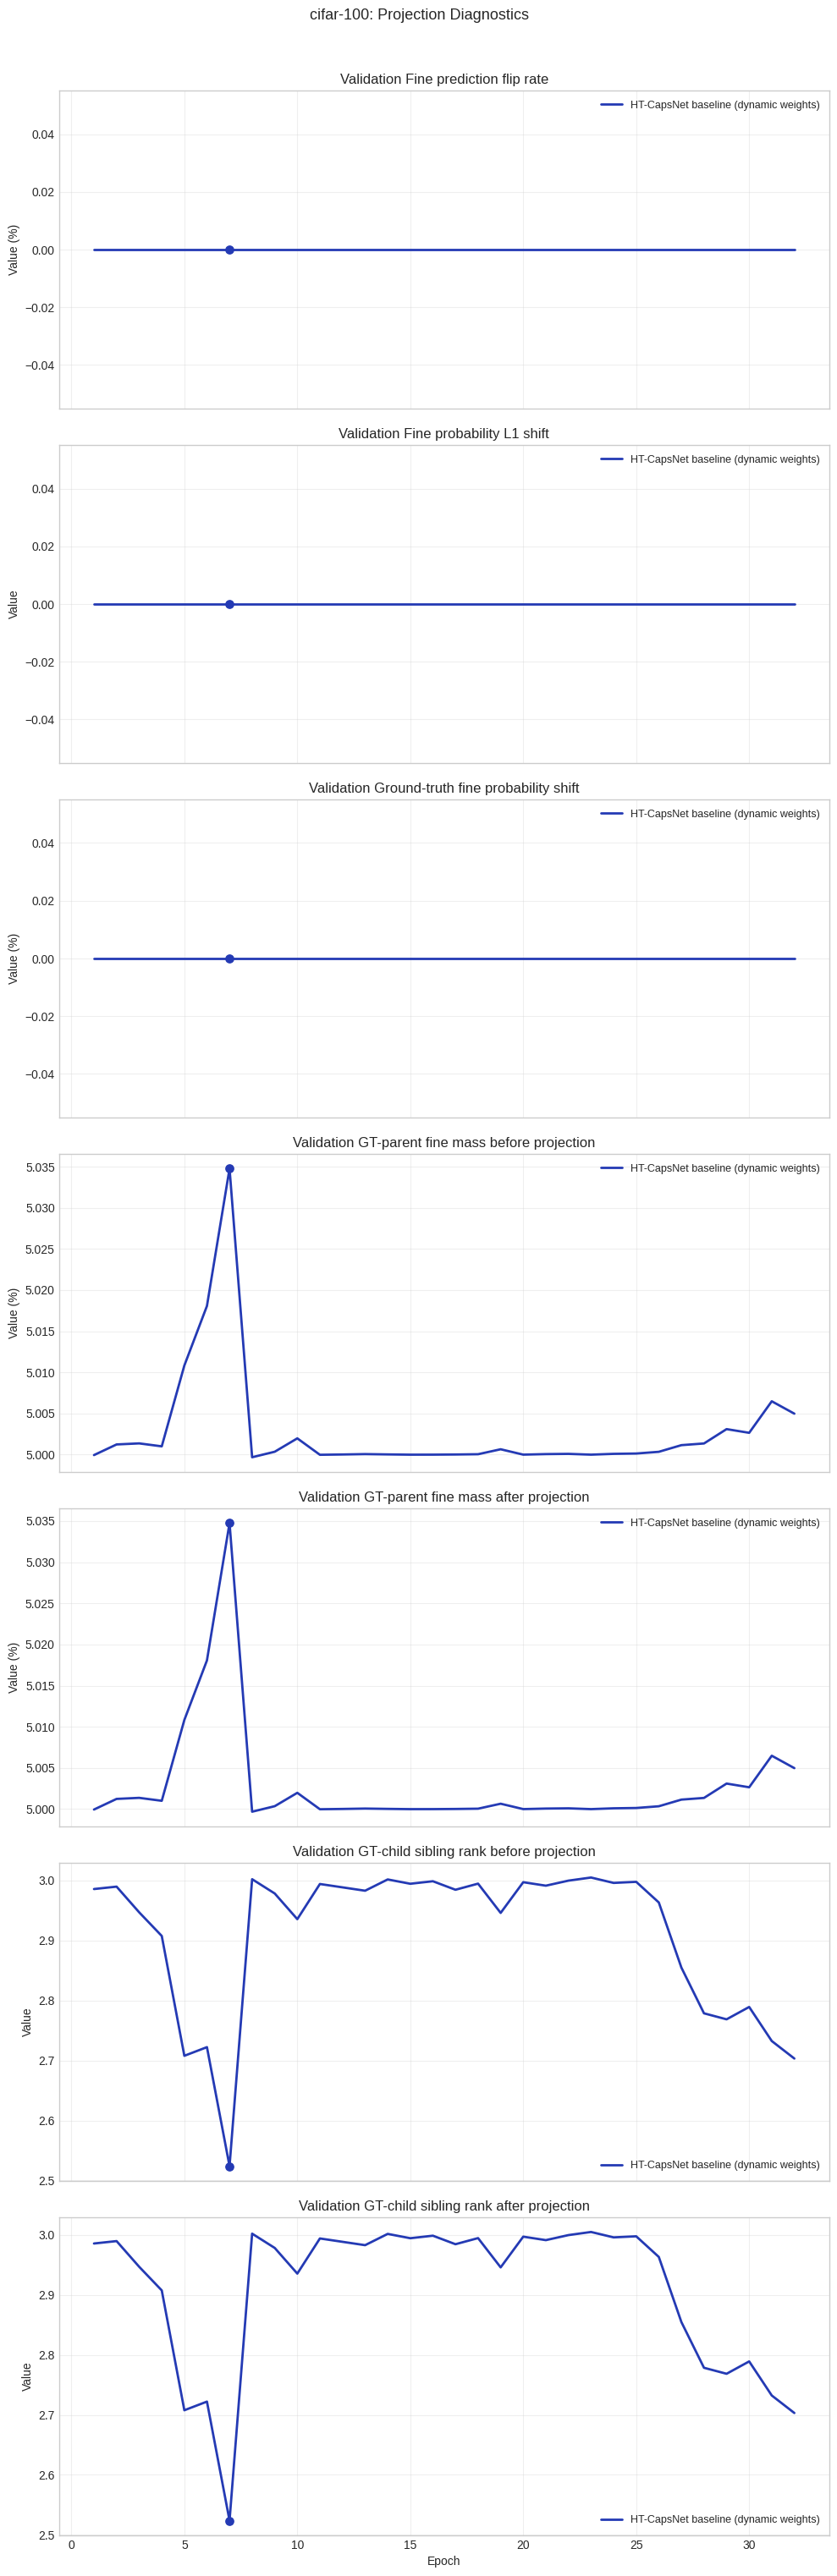

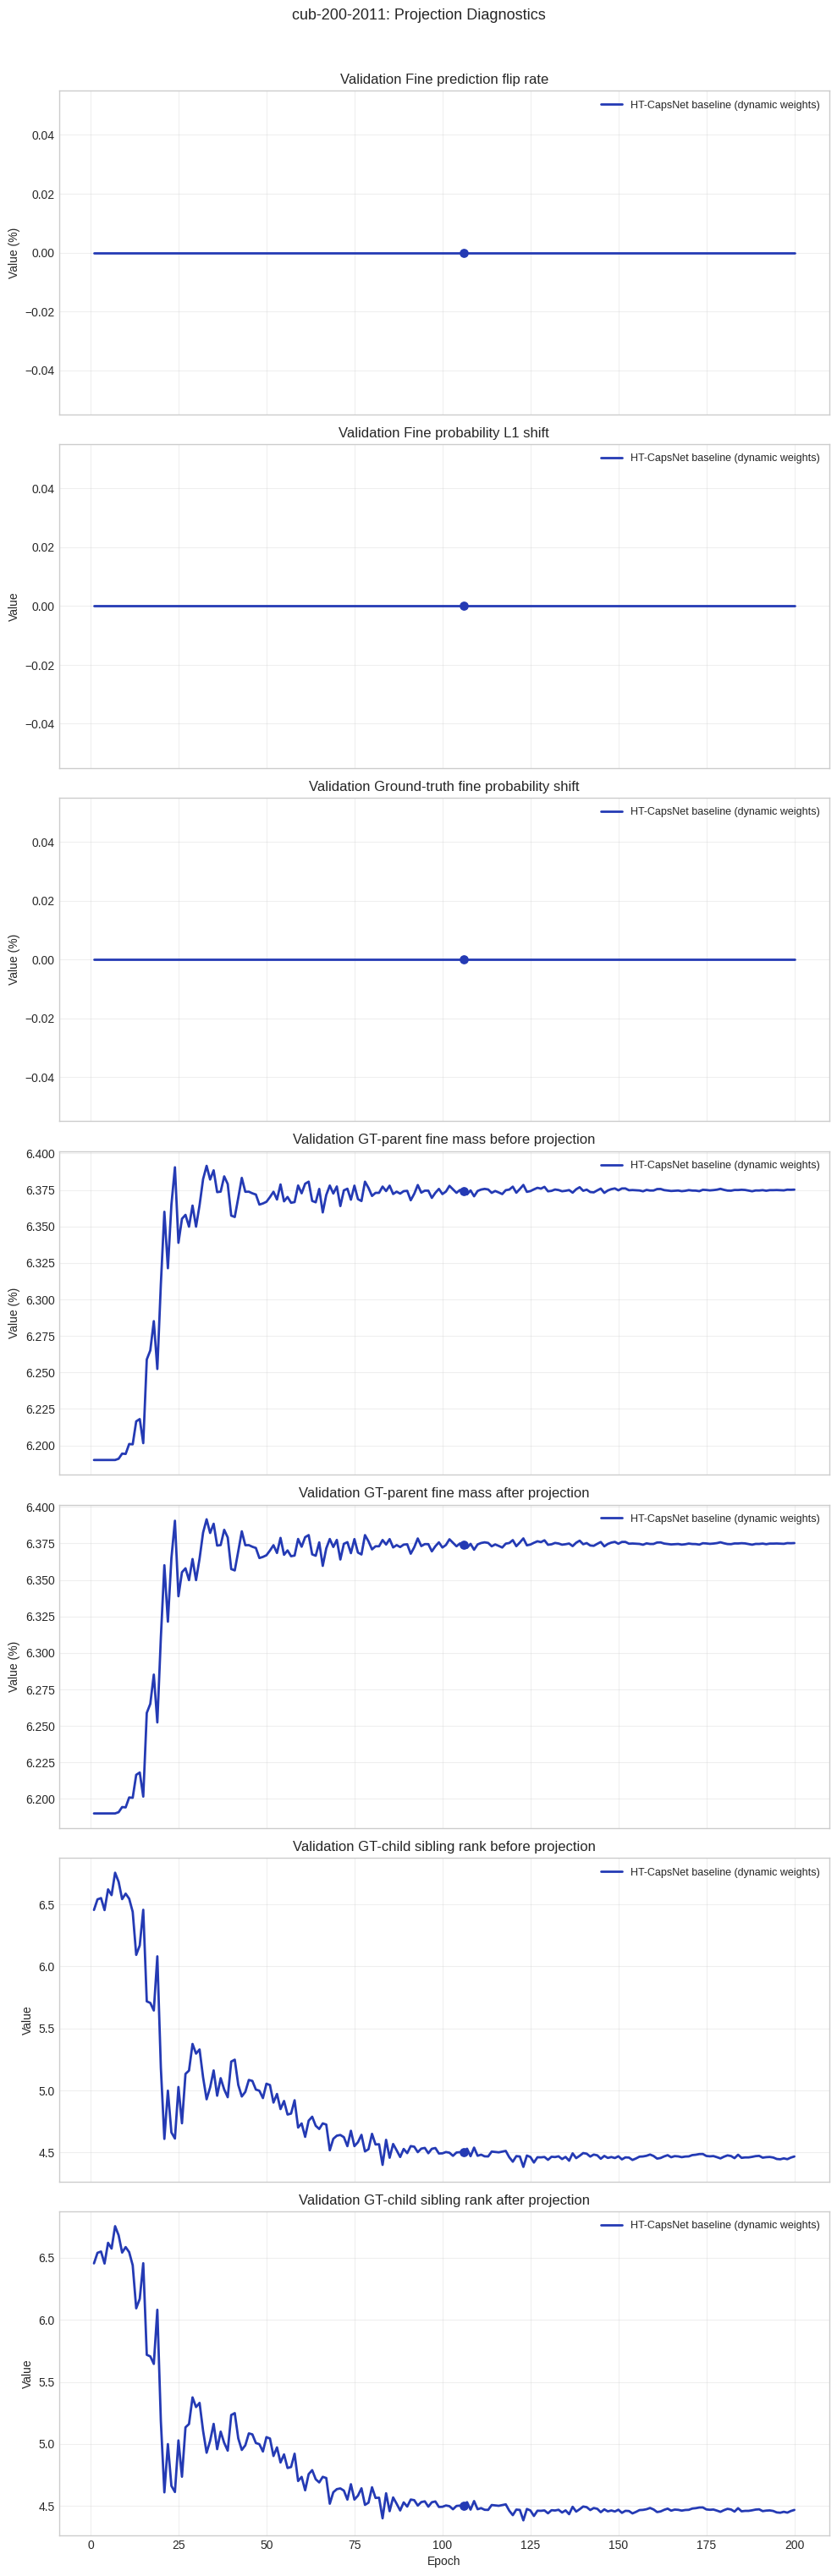

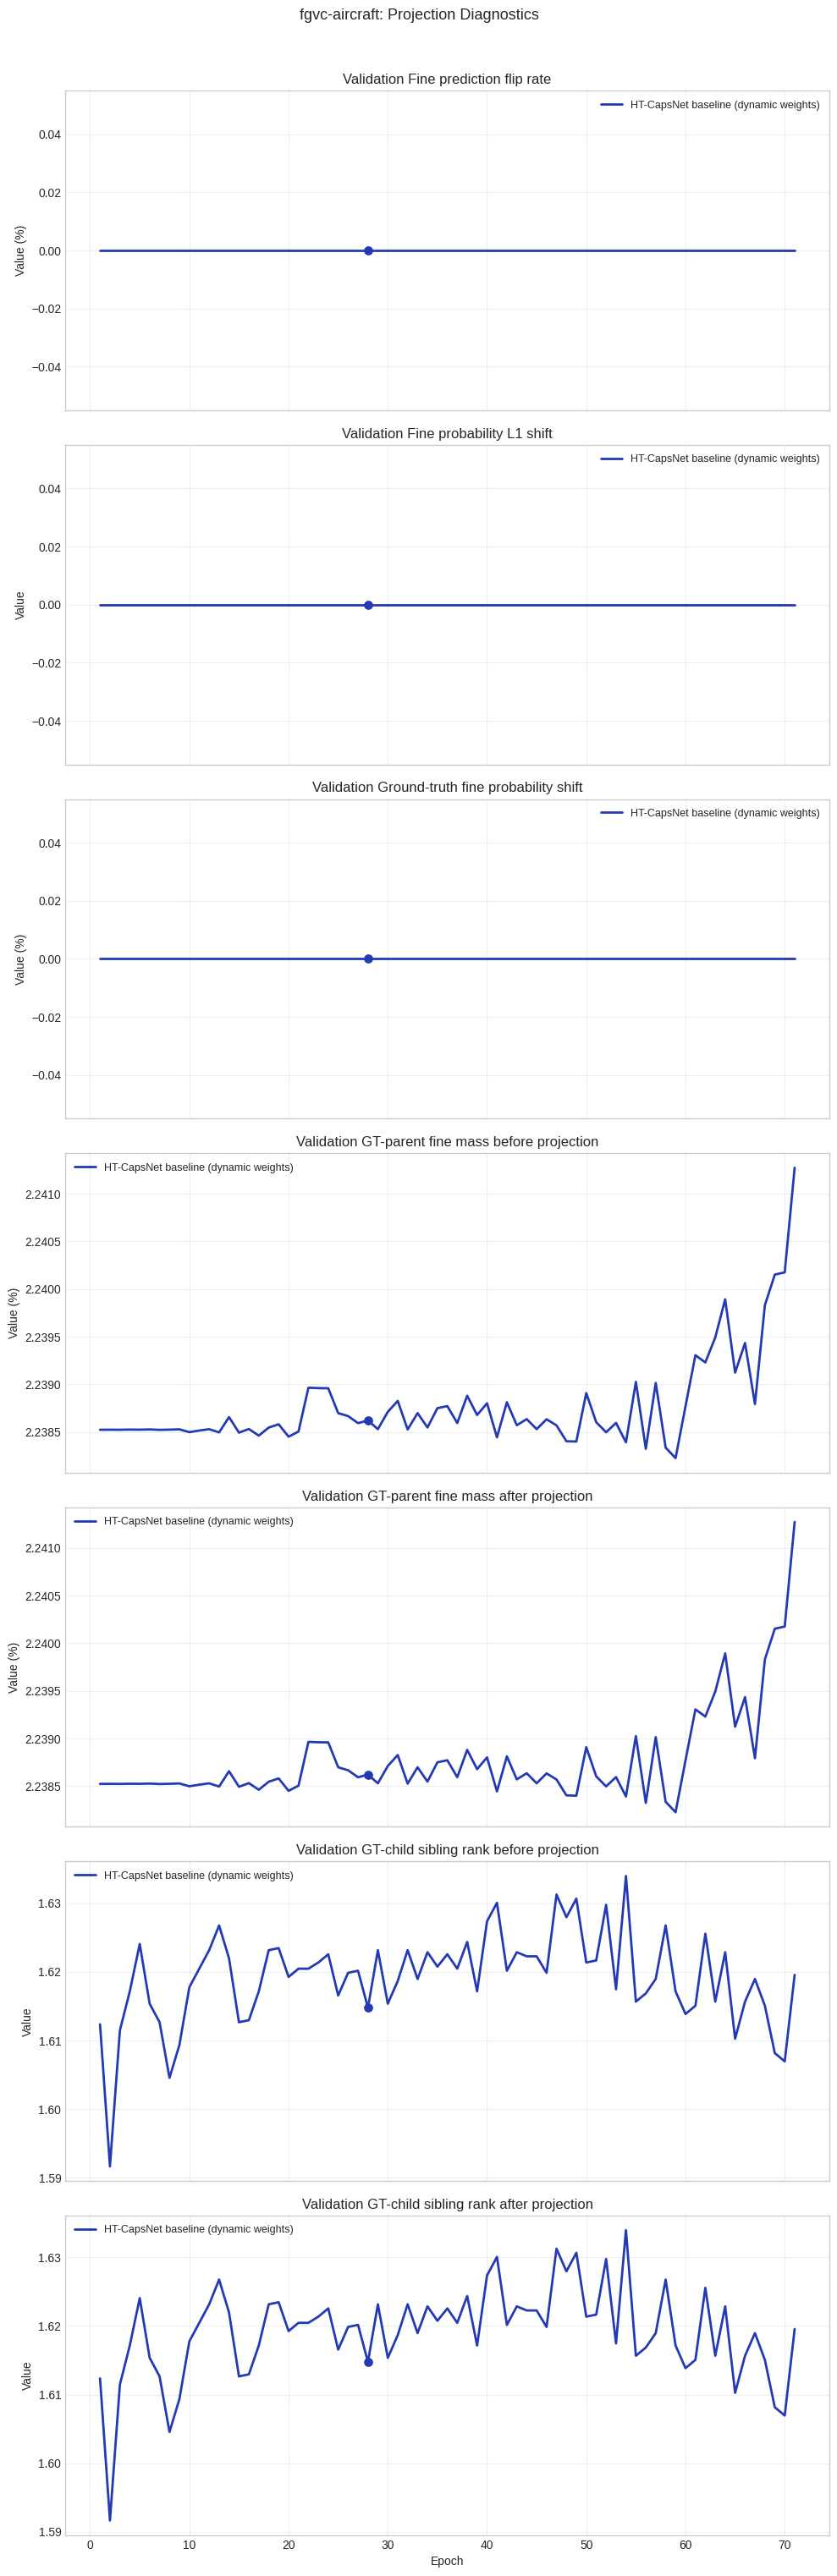

In [12]:
analysis.plot_projection_diagnostics(
    base_diag_specs=[
        ('proj_flip_rate_level_2', 'Fine prediction flip rate', True, 'val'),
        ('proj_delta_l1_level_2', 'Fine probability L1 shift', False, 'val'),
        ('proj_gt_prob_delta_level_2', 'Ground-truth fine probability shift', True, 'val'),
        ('gt_parent_mass_pre_l2', 'GT-parent fine mass before projection', True, 'val'),
        ('gt_parent_mass_post_l2', 'GT-parent fine mass after projection', True, 'val'),
        ('gt_child_rank_within_parent_pre_l2', 'GT-child sibling rank before projection', False, 'val'),
        ('gt_child_rank_within_parent_post_l2', 'GT-child sibling rank after projection', False, 'val'),
    ]
)

Interpretation note:

- Residual-after should be below residual-before when the projector is working numerically. That establishes constraint enforcement, not improved recognition.
- Increased ground-truth parent mass is favorable only if fine accuracy and sibling rank remain stable or improve. Lower sibling rank is better.
- Confirm activation from `proj_constraint_alpha`; generic pre/post probability diagnostics can also be logged as zero for non-HCC runs.
- Re-read the per-seed collapse table before attributing a low-variance HCC curve to stable learning.

## Final Selected-Checkpoint Test Tables

For every dataset, top-down rows use the top-down-selected checkpoint and independent rows use the independent-selected checkpoint. Tables include FPA, weighted AP, TICE, AHD, and every available per-level accuracy; multi-seed values are mean and sample standard deviation. Deltas are computed against the native HT-CapsNet baseline.

In [13]:
analysis.show_final_test_tables(allow_single_run=True)

### Dataset: `cifar-100`
Baseline run: **HT-CapsNet baseline (dynamic weights)**

| Metric | HT-CapsNet baseline (dynamic weights) (n=1) |
|---|---:|
| Best epoch (TD/Ind) | n/a/n/a |
| FPA independent ↑ | n/a |
| FPA top-down ↑ | n/a |
| wAP independent ↑ | n/a |
| wAP top-down ↑ | n/a |
| TICE independent ↓ | n/a |
| TICE top-down ↓ | n/a |
| AHD independent ↓ | n/a |
| AHD top-down ↓ | n/a |
| Acc independent coarse1 (L0) ↑ | n/a |
| Acc top-down coarse1 (L0) ↑ | n/a |
| Acc independent coarse2 (L1) ↑ | n/a |
| Acc top-down coarse2 (L1) ↑ | n/a |
| Acc independent fine (L2) ↑ | n/a |
| Acc top-down fine (L2) ↑ | n/a |

### Dataset: `cub-200-2011`
Baseline run: **HT-CapsNet baseline (dynamic weights)**

| Metric | HT-CapsNet baseline (dynamic weights) (n=3) |
|---|---:|
| Best epoch (TD/Ind) | 106.0 ± 46.9/85.7 ± 16.1 |
| FPA independent ↑ | 24.14% ± 0.41% |
| FPA top-down ↑ | 26.02% ± 0.74% |
| wAP independent ↑ | 34.78% ± 0.59% |
| wAP top-down ↑ | 33.49% ± 0.61% |
| TICE independent ↓ | 22.90% ± 0.39% |
| TICE top-down ↓ | 0.00% ± 0.00% |
| AHD independent ↓ | 1.374 ± 0.006 |
| AHD top-down ↓ | 1.344 ± 0.010 |
| Acc independent order (L0) ↑ | 84.01% ± 0.17% |
| Acc top-down order (L0) ↑ | 84.06% ± 0.20% |
| Acc independent family (L1) ↑ | 56.48% ± 0.14% |
| Acc top-down family (L1) ↑ | 55.52% ± 0.15% |
| Acc independent species (L2) ↑ | 27.45% ± 0.72% |
| Acc top-down species (L2) ↑ | 26.02% ± 0.74% |

### Dataset: `fgvc-aircraft`
Baseline run: **HT-CapsNet baseline (dynamic weights)**

| Metric | HT-CapsNet baseline (dynamic weights) (n=1) |
|---|---:|
| Best epoch (TD/Ind) | 183/183 |
| FPA independent ↑ | 2.97% |
| FPA top-down ↑ | 5.73% |
| wAP independent ↑ | 12.50% |
| wAP top-down ↑ | 11.39% |
| TICE independent ↓ | 59.77% |
| TICE top-down ↓ | 0.00% |
| AHD independent ↓ | 2.593 |
| AHD top-down ↓ | 2.543 |
| Acc independent manufacturer (L0) ↑ | 27.27% |
| Acc top-down manufacturer (L0) ↑ | 27.27% |
| Acc independent family (L1) ↑ | 13.56% |
| Acc top-down family (L1) ↑ | 12.66% |
| Acc independent variant (L2) ↑ | 7.32% |
| Acc top-down variant (L2) ↑ | 5.73% |

Reporting checklist:

- FPA, weighted AP, and accuracy are higher-is-better; TICE and AHD are lower-is-better. Accuracy/FPA/weighted-AP deltas are percentage-point differences, while AHD deltas are hierarchy-edge distances.
- Keep independent and top-down checkpoint families separate. Top-down TICE is zero by decoding construction.
- State seed counts and any collapse warning with the final numbers. Do not silently pool healthy and collapsed behavior into one claim.
- Describe CIFAR-100 as the paper/source-aligned local port setting, CUB as a unified-taxonomy extrapolation, Aircraft as a local dataset extrapolation, and HT-CapsNet + HCC as an exploratory compatibility ablation.
- A lex-versus-baseline difference mixes explicit gradient projection with the change from dynamic to unit level-loss weights.